# 00 - Data Audit & Cleaning

Goal of this notebook:

1. **Load** the raw, PII-stripped reservations parquet (cached locally by `src.data_loader`).
2. **Early row filters** (§2.5-2.6)
3. **Column audit** (§3)
   - **3.0**   pre-analysis engineering
   - **3.0.5** data-quality manual drops
   - **3.1**   100%-missing (auto)
   - **3.2**   obvious leakage (auto)
   - **3.3**   id/code/name trios (manual)
   - **3.4**   near-constants (manual)
   - **3.5**   free-text / opaque-IDs (manual)
   - **3.6**   numeric multicollinearity (manual)
   - **3.7**   categorical multicollinearity (manual)
4. **Row-level cleaning** (§4)
5. **Final engineering** (§5)
6. **Class-imbalance plan** (§6)
7. **Temporal split (point-in-time)** (§7)
8. **Column overview** (§8)
9. **Save** `Data/reservations_clean.parquet` (§9).
10. **Data dictionary** (§10)
11. **Feature roster export** (§11) -> `Data/feature_roster.json`

**Contextual decisions:**

- Target : `status == "Canceled"` (positive class). Rows are restricted to`{Canceled, CheckedOut, InHouse}`. `InHouse` is a **negative**: the guest checked in, so they did *not* cancel before arrival - a fully resolved outcome, merged with CheckedOut (the in-progress *stay* is irrelevant to the cancel-before-arrival target). `Confirmed` is pre-resolution (label unknown). `NoShow` is excluded because a no-show room is blocked shortly after the expected check-in and can only be resold for days way  past check-in. A no-show is operationally distinct from a cancellation we can oversell against.
- Leakage policy: any column that is only populated *after* the cancellation event is treated as leakage and dropped.


## 0 - Setup


In [1]:
# -----------------------------------------------------------------------------
# Imports - loading, styling, paths come from src/. 
# -----------------------------------------------------------------------------
from __future__ import annotations
import sys, json, warnings, time
from pathlib import Path

_t0 = time.perf_counter()
def _step(msg: str) -> None:
    print(f"  [{time.perf_counter()-_t0:5.2f}s] {msg}", flush=True)

_step("locating project root...")
_here = Path.cwd().resolve()
while not (_here / "pyproject.toml").exists():
    if _here == _here.parent:
        raise RuntimeError("could not find project root (no pyproject.toml above)")
    _here = _here.parent
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))

_step("importing numpy / pandas / matplotlib / seaborn...")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

_step("importing helpers from src...")
from src import (
    apply_stayery_style, color, categorical_palette, diverging_triplet,
    load_brand_config, load_locations,
    load_reservations, load_clean_reservations, strip_pii, PII_COLUMNS,
    add_country_region,
    data_dir, configs_dir, figures_dir, tables_dir, schema_config_path,
)

_step("applying style / output dirs / display options...")

apply_stayery_style()
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)

FIG_DIR = figures_dir() / "00_audit"
TBL_DIR = tables_dir()  / "00_audit"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)

_step("setup done.")


  [ 0.00s] locating project root...
  [ 0.01s] importing numpy / pandas / matplotlib / seaborn...
  [ 1.67s] importing helpers from src...
  [ 1.70s] applying style / output dirs / display options...
  [ 1.71s] setup done.


In [2]:
#Building audit logic and time stamps

column_decisions: dict[str, tuple[str, str, str]] = {}
audit_log: list[dict] = []
prev: tuple[int, int] | None = None


def snap(step: str, frame: pd.DataFrame, *, prev: tuple[int, int] | None = None,
         dropped_cols: list[str] | None = None) -> tuple[int, int]:
    n_rows, n_cols = frame.shape
    if prev is not None:
        d_rows, d_cols = prev[0] - n_rows, prev[1] - n_cols
        delta = []
        if d_cols: delta.append(f"-{d_cols} cols")
        if d_rows: delta.append(f"-{d_rows:,} rows")
        delta_str = f"   ({', '.join(delta)})" if delta else "   (no change)"
    else:
        delta_str = ""
    print(f"  > {step:<55s}  {n_rows:>8,} rows x {n_cols:>3} cols{delta_str}")
    audit_log.append({"step": step, "rows": n_rows, "cols": n_cols,
                      "dropped_cols": list(dropped_cols or [])})
    return (n_rows, n_cols)


def record_drop(cols: list[str], reason: str, step: str) -> None:
    for c in cols:
        column_decisions[c] = ("dropped", reason, step)


def apply_manual_drops(drops: list[str], reason: str, step: str) -> None:
    global df, prev
    present      = [c for c in drops if c in df.columns]
    already_gone = [c for c in drops if c not in df.columns]
    if already_gone:
        print(f"  note: skipping (already dropped earlier): {already_gone}")
    if present:
        df = df.drop(columns=present)
        record_drop(present, reason, step)
        prev = snap(f"{step} manual drops applied", df, prev=prev, dropped_cols=present)
        print(f"  dropped: {present}")
    else:
        print(f"  no drops applied (list empty).")
        prev = snap(f"{step} manual drops (no-op)", df, prev=prev)


def reset_audit_state() -> None:
    """Wipe column_decisions / audit_log / prev so a full re-run starts clean."""
    global column_decisions, audit_log, prev
    column_decisions.clear()
    audit_log.clear()
    prev = None
    print("  audit state reset (column_decisions / audit_log / prev).")

reset_audit_state()


  audit state reset (column_decisions / audit_log / prev).


## Engineered columns at a glance

Built in §3.0 and §5 and persisted to the cleaned parquet. 
The §8 overview table records the final disposition of every original column. 
§10 prints the full data dictionary against the saved frame.

**Temporal / stay (§3.0.b, §5)**
- `lead_time_days` - (arrival - created) in days; timestamp-precision so negative-clip in §4.2 sees sub-day shifts.
- `los_nights` - `(departure.date - arrival.date)` in days. Sat 17:00 -> Sun 08:00 = 1 night.
- `arrival_dow`, `arrival_month`, `is_weekend_arrival`, `stay_bucket` - basic calendar features.

**Money (§3.0.b, §5)**
- `gross_amount` = numeric coercion of `totalGrossAmount_amount` which used to be string.
- `gross_per_night` = `gross_amount / los_nights` (zero LOS -> NaN).
- `log_gross_amount` = `log1p(clip(gross_amount, 0))` to dampen the tail for linear models.
- `diff_gross_cancellation_fee` = `gross_amount - cancellationFee_fee_amount`. How much the guest forfeits by cancelling.

**Party / context (§5)**
- `adults_n` - numeric coercion of `adults`.
- `is_international` - `countryCode != 'DE'`.
- `has_children` - 1 if `children > 0` or `childrenAges` non-empty (family booking).
- `guest_country_region` - structural collapse of `primaryGuest_address_countryCode` into DACH (DE/AT/CH) / GB / EU_other / RoW / Unknown
- `has_promo` - any non-empty `promoCode`.
- `has_corporate_code` - any non-empty `corporateCode`.
- `has_group` - any non-empty `blockId` OR `groupName`.

**Company resolution (§3.0.c)**
- `company_name_combined` - **intermediate only** (coalesce of `booker_company_name` -> `primaryGuest_company_name`); used to feed `company_name_clean`
- `company_name_clean` - fuzzy-clustered canonical company name.

**Rate plan (§3.0.d-e)**
Different columns were tried and quantified in terms of performance. High order cardinality can be an issue. Only one column will be used in the model later on.
- `ratePlan_type` - coarse bucket: `nonref` / `flexible` / `corporate` / `promo` / `comp` / `other` / `unknown`.
- `ratePlan_category` - mid-granularity. All nonref variants pooled into `nonref`; rare buckets (< 50 rows) folded into `other`.
- `is_nonref` - exists during §3.0 but is dropped in §3.7 because it is collinear with `ratePlan_type == 'nonref'`.

**Company history (§5.2)**
- `has_company` - a (clustered) company is attached to the booking.
- `is_repeat_company` - the company has >=1 prior booking (by `created`).
- `company_prior_bookings` - count of the company's earlier bookings.
- `company_prior_cancel_rate` - cancel rate over those priors (NaN if none).

**Modelling split (§7)**
- `temporal_split` - `train` (oldest 60%) / `val` (next 15%) / `test` (newest 25%) by `arrival`.
- `is_temporal_test`, `is_temporal_val` - 1/0 flags for the test / val blocks.


## 1 - Load reservations


PII columns are stripped inside the loader (see `src.data_loader.PII_COLUMNS`).
The cache lives in `Data/reservations_raw_no_pii.parquet`; reset it by running `uv run python main.py refresh` or `load_reservations(force_refresh=True)`.


In [3]:
df = load_reservations()
prev = snap("loaded raw parquet", df)
ORIGINAL_COLUMNS = list(df.columns)   # snapshot for the final decision table
print(f"  PII columns stripped: {len(PII_COLUMNS)}")
print(f"  arrival range: {df['arrival'].min()}  -  {df['arrival'].max()}")
print(f"  created range: {df['created'].min()}  -  {df['created'].max()}")


loading cached parquet: reservations_raw_no_pii.parquet


  > loaded raw parquet                                        214,941 rows x  73 cols
  PII columns stripped: 27
  arrival range: 2019-01-14 14:00:00+00:00  -  2027-12-26 14:00:00+00:00
  created range: 2019-01-07 13:52:18+00:00  -  2026-06-23 12:34:17+00:00


## 2 - Status distribution & target definition


Raw status counts.

| status     | included in model?              | why                                                                                          |
|------------|---------------------------------|----------------------------------------------------------------------------------------------|
| Canceled   | positive class                  | the event we are predicting                                                                  |
| CheckedOut | negative class                  | booking fully resolved without cancellation                                                  |
| InHouse    | negative class                  | guest checked in -> did not cancel before arrival; resolved negative, merged with CheckedOut |
| Confirmed  | dropped                         | label not yet known - booking has not yet resolved                                           |
| NoShow     | **dropped from this model**     | not a cancel-before-arrival event - a *separate* empty-room risk (see note below)             |

**Note on no-shows.** A no-show is *not* a cancellation: the booking is never cancelled, the guest simply doesn't arrive, so there is no cancellation event/time and the room only frees up at/after the expected check-in (minus a hold). It produces an empty room like a cancellation, but with almost no lead time to resell. We therefore handle it **outside** this cancellation model:
(1) the cancellation model excludes no-shows 
(2) a separate no-show *rate/model* feeds the overbooking allowance (`E[empty] = E[cancellations] + E[no-shows]`);
(3) the live occupancy view reflects no-shows from the raw bookings in real time. No-show rows remain in the raw parquet but not in modelling data

In [4]:
status_counts = df["status"].value_counts(dropna=False).to_frame("count")
status_counts["share"] = status_counts["count"] / status_counts["count"].sum()

total_share = status_counts["share"].sum()
print(f"  rows accounted for: {status_counts['count'].sum():,} / {len(df):,}")
print(f"  share total       : {total_share:.4%} ")
assert abs(total_share - 1.0) < 1e-9, "status shares do not sum to 1 - investigate"
print()
display(status_counts.style.format({"share": "{:.2%}"}))

# Target preview 
modelable = df[df["status"].isin({"Canceled", "CheckedOut", "InHouse"})]
y_share_modelable = (modelable["status"] == "Canceled").mean()
print(f"\n positive-class share after filtering (Canceled vs CheckedOut+InHouse): "
      f"{y_share_modelable:.2%}")
print(f" As long as mild imbalance is present (>20% in minority class), no resampling is needed.\n"
      f" If class weighting is used, pair it with "
      f"probability calibration so p_cancel stays meaningful for the overbooking math.")


  rows accounted for: 214,941 / 214,941
  share total       : 100.0000% 



,count,share
status,,
CheckedOut,161751,75.25%
Canceled,45007,20.94%
Confirmed,5436,2.53%
NoShow,2198,1.02%
InHouse,549,0.26%



 positive-class share after filtering (Canceled vs CheckedOut+InHouse): 21.71%
 As long as mild imbalance is present (>20% in minority class), no resampling is needed.
 If class weighting is used, pair it with probability calibration so p_cancel stays meaningful for the overbooking math.


## 2.5 - Early row filters

Filtering target categories and booking after arrival cutoff. These filters are put in place to simplify column audit.
The row-level cleaning in §4 picks up again on a more granular level (duplicates, lead-time fix, outliers, tiny props, final QC).

In [5]:
TARGET_STATUSES = {"Canceled", "CheckedOut", "InHouse"}
before_status = df["status"].value_counts(dropna=False).to_dict()

n_before = len(df)
df = df[df["status"].isin(TARGET_STATUSES)].copy()
n_dropped = n_before - len(df)
print(f"  dropped {n_dropped:,} rows in non-target statuses:")
for s, c in before_status.items():
    if s not in TARGET_STATUSES:
        print(f"    - {s}: {c:,}")
print(f"\n  positive-class share (Canceled / total): "
      f"{(df['status'] == 'Canceled').mean():.2%}")
print(f"  Canceled / CheckedOut / InHouse: "
      f"{(df['status']=='Canceled').sum():,} / "
      f"{(df['status']=='CheckedOut').sum():,} / "
      f"{(df['status']=='InHouse').sum():,}")
prev = snap("2.5 filtered to Canceled+CheckedOut+InHouse", df, prev=prev)


  dropped 7,634 rows in non-target statuses:
    - Confirmed: 5,436
    - NoShow: 2,198

  positive-class share (Canceled / total): 21.71%
  Canceled / CheckedOut / InHouse: 45,007 / 161,751 / 549
  > 2.5 filtered to Canceled+CheckedOut+InHouse               207,307 rows x  73 cols   (-7,634 rows)


## 2.6 - Arrival window (historical floor + future cutoff)

Two bounds are applied to `arrival`:

- **Floor** `ARRIVAL_FLOOR = 2022-08-01`: everything earlier is the COVID time or times where not many locations where open (mass cancellations, flexible-rate surges. See the development over time in `experiments/cancellation_rate_over_time`). I am assumin an entirely different distribution which would make the model very unreliable.
- **Future cutoff** `ARRIVAL_CUTOFF = today - GRACE_DAYS`: bookings arriving on/after this are outcome-not-yet-established and dropped. The grace window protects against in-flight check-ins / late-cancel reflections not yet in the source table, and avoids the recent-window selection bias (only quick-resolving bookings would otherwise survive). In the same experiment file you can see that reducing the grace period further would not be the best idea. I recommend keeping it around 2 or 3 days.

In [6]:
# the cutoff is run-date-dependent, so ARRIVAL_FLOOR / ARRIVAL_CUTOFF / RUN_TIMESTAMP are stamped into
# Data/reservations_clean_meta.json in section 9 for reproducibility.
ARRIVAL_FLOOR  = pd.Timestamp("2022-08-01", tz="UTC")
GRACE_DAYS     = 3
RUN_TIMESTAMP  = pd.to_datetime(df["created"], utc=True).max()   # DATA-anchored "now" (extraction), not wall-clock -> reproduzierbar
ARRIVAL_CUTOFF = (RUN_TIMESTAMP.normalize() - pd.Timedelta(days=GRACE_DAYS))

n_floor = int((df["arrival"] < ARRIVAL_FLOOR).sum())
df = df[df["arrival"] >= ARRIVAL_FLOOR].copy()
print(f"  ARRIVAL_FLOOR  = {ARRIVAL_FLOOR.date()} (exclude pre-recovery / COVID regime)")
print(f"  dropped {n_floor:,} rows with arrival < {ARRIVAL_FLOOR.date()}")
prev = snap("2.6 dropped pre-floor (COVID-era) arrivals", df, prev=prev)

n_future = int((df["arrival"] >= ARRIVAL_CUTOFF).sum())
df = df[df["arrival"] < ARRIVAL_CUTOFF].copy()
print(f"  ARRIVAL_CUTOFF = {ARRIVAL_CUTOFF.date()} (today - {GRACE_DAYS} days, dynamic)")
print(f"  dropped {n_future:,} rows with arrival >= {ARRIVAL_CUTOFF.date()}")
prev = snap("2.6 dropped future arrivals", df, prev=prev)

  ARRIVAL_FLOOR  = 2022-08-01 (exclude pre-recovery / COVID regime)
  dropped 28,396 rows with arrival < 2022-08-01
  > 2.6 dropped pre-floor (COVID-era) arrivals                178,911 rows x  73 cols   (-28,396 rows)
  ARRIVAL_CUTOFF = 2026-06-20 (today - 3 days, dynamic)
  dropped 1,880 rows with arrival >= 2026-06-20
  > 2.6 dropped future arrivals                               177,031 rows x  73 cols   (-1,880 rows)


## 3 - Column-level audit

- **3.0**   pre-analysis engineering
- **3.0.5** data-quality manual drops
- **3.1**   100%-missing columns -> **auto-drop**
- **3.2**   obvious leakage columns -> **auto-drop**
- **3.3**   duplicate-information trios (id / code / name) -> inspect + manual drop
- **3.4**   near-constant / single-value columns -> inspect + manual drop
- **3.5**   free-text / description columns -> inspect + manual drop
- **3.6**   numeric multicollinearity (Spearman heatmap) -> inspect + manual drop
- **3.7**   categorical association (Cramer's V) -> inspect + manual drop

### 3.0 - Pre-analysis engineering

Everything created here is documented again in the "Engineered columns at a glance" cell at the top and in the §10 data dictionary.

- **a - Channel merging:** `ChannelManager` rows take the real OTA from `source` (-> Booking.com / Expedia / Airbnb / ...), rename map applied.
- **b - Dates:** `los_nights`, `lead_time_days`.
- **c - Company resolution:** `company_name_combined` (booker preferred, primary-guest fallback) -> fuzzy-clustered `company_name_clean`.
- **d - Rate plan:** `ratePlan_type` (coarse), `ratePlan_category` (nonref pooled, rare < 50 -> `other`), `is_nonref` (binary)
- **e - Group flag:** `has_group`.
- **f - Cancellation economics:** `diff_gross_cancellation_fee`.
- **g - Party / context flags:** `adults_n`, `has_promo`, `has_corporate_code`, `has_children`, `is_international`, `guest_country_region`
- **h - Calendar:** `arrival_dow`, `arrival_month`, `is_weekend_arrival`, `stay_bucket`.
- **i - Money tail:** `log_gross_amount`.
- **j - Cleanup:** drop raw columns now subsumed by the engineered ones.


All engineered features are built before the §3 audit (so correlations, near-constant checks and Cramer's V all see them) and **before** §4 row cleaning.

For OTA bookings the source system reports `channelCode = "ChannelManager"` but the actual OTA name lives in `source`. Direct bookings (`Ibe`, `Direct`) already have `channelCode` correct and `source` empty. The pipeline rewrites `channelCode` from `source` where applicable and drops`source`.

**B. Diagnostic numerics**
- `lead_time_days` = `(arrival - created)` in days
- `los_nights` = `(departure.date - arrival.date)`
- `gross_amount` = numeric coercion of `totalGrossAmount_amount`.
- `gross_per_night` = `gross_amount / los_nights`.

**C. Company-name resolution.**
- `company_name_combined` = `COALESCE(booker_company_name, primaryGuest_company_name)`. **Intermediate only** as it feeds `company_name_clean`, then dropped in §3.0.5.
- `company_name_clean` = fuzzy-clustered canonical company name

**D. Rate-plan classification.**
- `ratePlan_name` normalised in-place (lowercase, collapsed whitespace).
- `is_nonref` = non-refundable regex flag.
- `ratePlan_type` = coarse bucket (nonref/flexible/corporate/promo/comp/other/unknown).
- `ratePlan_category` = mid-granularity; rare buckets folded to `'other'`.

**E. Group bookings.**
- `has_group` = `blockId` or `groupName` is non-empty.

**F. Cancellation economics.**
- `diff_gross_cancellation_fee` = `gross_amount - cancellationFee_fee_amount`.

**G. Calendar features.**
- `arrival_dow`, `arrival_month`, `is_weekend_arrival`, `stay_bucket`.

**H. Party / context flags.**
- `adults_n`, `is_international`, `has_promo`, `has_corporate_code`.

**I. Money tail damping.**
- `log_gross_amount` = `log1p(clip(gross_amount, 0))`.

**J. Drop now-subsumed raw columns** (§3.0.j): `promoCode`, `corporateCode`,
`adults`, `booker_company_name`, `primaryGuest_company_name`.


In [7]:
# ---- 3.0.a - Channel merging --------------------------------------------
if "source" in df.columns and "channelCode" in df.columns:
    chan = df["channelCode"].astype("string")
    src  = df["source"].astype("string")
    mask = (chan == "ChannelManager") & src.notna() & (src.str.len() > 0)
    n_subs = int(mask.sum())
    df.loc[mask, "channelCode"] = src[mask]
    df = df.drop(columns=["source"])
    record_drop(["source"], "merged into channelCode (3.0)", "3.0")
    print(f"  substituted {n_subs:,} 'ChannelManager' rows with the source value, "
          f"then dropped source.")
    print(f"  channelCode values: {sorted(df['channelCode'].dropna().unique().tolist())}")


  substituted 108,724 'ChannelManager' rows with the source value, then dropped source.
  channelCode values: ['Airbnb', 'Apartmentservice', 'Booking.com', 'CRC Corporate Rates Club', 'Direct', 'Expedia', 'Expedia Affiliate Network', 'GDS', 'HRS', 'HomeLike', 'HousingAnywhere', 'Ibe', 'Other', 'Rydoo', 'SilverDoor', 'Synxis', 'Tomas', 'TravelPerk', 'ehotel AG', 'feratel']


In [8]:
# OTA rename cleaning.

CHANNEL_RENAME = {
    "BookingCom":                "Booking.com",
    "Expedia Affiliate Network": "Expedia",
}
df["channelCode"] = df["channelCode"].astype("string").replace(CHANNEL_RENAME)

print(f"  channelCode rename applied: {CHANNEL_RENAME}")
print(f"  final channelCode distribution ({df['channelCode'].nunique()} levels):")
print(df["channelCode"].value_counts(dropna=False).to_string())


  channelCode rename applied: {'BookingCom': 'Booking.com', 'Expedia Affiliate Network': 'Expedia'}
  final channelCode distribution (19 levels):
channelCode
Booking.com                 80709
Ibe                         44943
Direct                      23364
HRS                         11516
Expedia                      7375
Airbnb                       6558
Synxis                        944
CRC Corporate Rates Club      685
Rydoo                         295
Other                         241
GDS                           175
TravelPerk                    123
feratel                        47
HomeLike                       36
Tomas                          11
Apartmentservice                4
SilverDoor                      3
ehotel AG                       1
HousingAnywhere                 1


In [9]:
# ---- 3.0.b - LOS + lead_time --------------------------------
arr_ts = pd.to_datetime(df["arrival"],   utc=True)
dep_ts = pd.to_datetime(df["departure"], utc=True)
crt_ts = pd.to_datetime(df["created"],   utc=True)

df["lead_time_days"] = (arr_ts - crt_ts) / pd.Timedelta(days=1)
df["los_nights"]     = ((dep_ts.dt.normalize() - arr_ts.dt.normalize())
                        / pd.Timedelta(days=1)).astype("Int64")

df["gross_amount"]    = pd.to_numeric(df["totalGrossAmount_amount"], errors="coerce")
df["gross_per_night"] = df["gross_amount"] / df["los_nights"].replace(0, pd.NA)


In [10]:
# ---- 3.0.c - Company name (booker preferred, primary-guest fallback) ----
# Note: the separate `company_name` column on the reservation is wholly NA
if "company_name_combined" in df.columns:
    print(f"  company_name_combined already present "
          f"({df['company_name_combined'].notna().sum():,} non-null) - re-using.")
else:
    booker_co = (df["booker_company_name"].astype("string")
                 if "booker_company_name" in df.columns
                 else pd.Series(pd.NA, index=df.index, dtype="string"))
    guest_co  = (df["primaryGuest_company_name"].astype("string")
                 if "primaryGuest_company_name" in df.columns
                 else pd.Series(pd.NA, index=df.index, dtype="string"))
    booker_co = booker_co.where(booker_co.str.len() > 0, other=pd.NA)
    guest_co  = guest_co.where(guest_co.str.len() > 0,  other=pd.NA)
    df["company_name_combined"] = booker_co.combine_first(guest_co)
    print(f"  company_name_combined: "
          f"{df['company_name_combined'].notna().sum():,} non-null "
          f"(booker filled: {booker_co.notna().sum():,}, "
          f"guest fallback: {(booker_co.isna() & guest_co.notna()).sum():,})")


  company_name_combined: 55,982 non-null (booker filled: 55,664, guest fallback: 318)


In [11]:
# Idempotency guard: skip the whole clustering if the clean column already exists.
if "company_name_clean" in df.columns:
    print(f"  company_name_clean already present "
          f"({df['company_name_clean'].nunique():,} unique groups) - re-using.")
else:
    import re, time, unicodedata
    from collections import defaultdict
    import numpy as np
    import pandas as pd
    from rapidfuzz import fuzz, process
    
    # === CONFIG ===================================================================
    COMPANY_COL      = "company_name_combined"
    CLEAN_COL        = "company_name_clean"
    FUZZ_THRESHOLD   = 85       # initial-pass cutoff
    REP_THRESHOLD    = 85       # post-pass: members must be this close to the rep
    BLOCK_PREFIX_LEN = 3        # first 3 chars of each token = blocking key
    MAX_BLOCK_SIZE   = 2000     # safety cap; oversize blocks are skipped + warned
    SCORER           = fuzz.token_sort_ratio   # stricter than token_set_ratio
    
    # === NORMALISATION ============================================================
    LEGAL_FORMS = [
        "ag & co. kg", "ag & co kg", "gmbh & co. kg", "gmbh & co kg",
        "se & co. kg", "se & co kg", "aktiengesellschaft",
        "gmbh", "ag", "se", "kg", "ohg", "ug", "e.v.", "ev",
        "limited", "ltd", "ltd.", "inc", "inc.", "corp", "corp.",
        "company", "co.", "co", "plc", "llc", "n.v.", "nv",
        "sa", "s.a.", "spa", "s.p.a.", "bv", "b.v."
    ]
    SEGMENT_PATTERNS = [
        r",?\s*segment\s+\S+.*$",
        r",?\s*pg\s+\d+.*$",
        r",?\s*region\s+\S+.*$",
        r",?\s*division\s+\S+.*$",
        r",?\s*business\s*unit\s+\S+.*$",
        r"\s+-\s+.*$", 
    ]
    
    def normalise(name) -> str:
        if pd.isna(name): return ""
        s = str(name).strip().lower()
        s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
        for pat in SEGMENT_PATTERNS:
            s = re.sub(pat, "", s, flags=re.IGNORECASE)
        s = re.sub(r"[^a-z0-9\s]", " ", s)
        for lf in LEGAL_FORMS:
            s = re.sub(rf"\b{re.escape(lf)}\b", " ", s)
        return re.sub(r"\s+", " ", s).strip()
    
    # === UNION-FIND ===============================================================
    class UnionFind:
        def __init__(self, n):
            self.parent = np.arange(n)
            self.rank   = np.zeros(n, dtype=np.int8)
        def find(self, x):
            root = x
            while self.parent[root] != root:
                root = self.parent[root]
            while self.parent[x] != root:
                self.parent[x], x = root, self.parent[x]
            return root
        def union(self, a, b):
            ra, rb = self.find(a), self.find(b)
            if ra == rb: return
            if self.rank[ra] < self.rank[rb]:
                ra, rb = rb, ra
            self.parent[rb] = ra
            if self.rank[ra] == self.rank[rb]:
                self.rank[ra] += 1
    
    # === PIPELINE =================================================================
    t0 = time.time()
    
    # 1) Unique values, frequency-sorted (so the highest-frequency variant becomes
    #    the cluster representative automatically).
    freq       = df[COMPANY_COL].value_counts(dropna=True)
    unique     = freq.index.to_numpy()
    N          = len(unique)
    normalised = np.array([normalise(s) for s in unique])
    print(f"  {N:,} unique values normalised in {time.time()-t0:.1f}s")
    
    # 2) Multi-key blocking on first 3 chars of each token.
    blocks: dict[str, list[int]] = defaultdict(list)
    for i, nm in enumerate(normalised):
        if not nm: continue
        for key in {tok[:BLOCK_PREFIX_LEN] for tok in nm.split() if tok}:
            blocks[key].append(i)
    print(f"  {len(blocks):,} blocks built in {time.time()-t0:.1f}s")
    
    # 3) Within-block pairwise similarity via process.cdist (vectorised, MT).
    uf, n_pairs, big_blocks = UnionFind(N), 0, []
    for key, idxs in blocks.items():
        if len(idxs) < 2:
            continue
        if len(idxs) > MAX_BLOCK_SIZE:
            big_blocks.append((key, len(idxs)))
            continue
        norms = normalised[idxs].tolist()
        sims = process.cdist(norms, norms,
                             scorer=SCORER,
                             score_cutoff=FUZZ_THRESHOLD,
                             dtype=np.uint8,
                             workers=-1)
        rows, cols = np.where(sims >= FUZZ_THRESHOLD)
        mask = rows < cols
        for r, c in zip(rows[mask], cols[mask]):
            uf.union(idxs[r], idxs[c])
            n_pairs += 1
    print(f"  {n_pairs:,} variant pairs merged in {time.time()-t0:.1f}s")
    if big_blocks:
        print(f"  WARNING: skipped {len(big_blocks)} oversized blocks {big_blocks[:5]} "
              f"- extend LEGAL_FORMS / SEGMENT_PATTERNS.")
    
    # 4) Initial canonical map: highest-frequency variant per cluster.
    roots = np.fromiter((uf.find(i) for i in range(N)), dtype=np.int64, count=N)
    cluster_rep: dict[int, int] = {}
    for i in range(N):
        r = int(roots[i])
        if r not in cluster_rep:
            cluster_rep[r] = i
    
    canonical = {unique[i]: unique[cluster_rep[int(roots[i])]] for i in range(N)}
    
    # 5) Anti-chaining post-pass: every cluster member must be directly similar to
    #    the representative. Transitively-bridged members are ejected to singletons.
    norm_map = dict(zip(unique.tolist(), normalised.tolist()))
    groups = defaultdict(list)
    for orig, can in canonical.items():
        groups[can].append(orig)
    
    ejected = 0
    for can, members in list(groups.items()):
        if len(members) < 2:
            continue
        can_norm = norm_map.get(can, "")
        for m in members:
            if m == can:
                continue
            score = SCORER(norm_map.get(m, ""), can_norm)
            if score < REP_THRESHOLD:
                canonical[m] = m
                ejected += 1
    print(f"  ejected {ejected:,} transitively-chained members back to singletons")
    
    # 6) Write back.
    df[CLEAN_COL] = df[COMPANY_COL].map(canonical).fillna(df[COMPANY_COL])
    print(f"  total elapsed: {time.time()-t0:.1f}s")
    print(f"  before: {df[COMPANY_COL].nunique():,}  ->  after: {df[CLEAN_COL].nunique():,}")
    
    # 7) Audit table - eyeball this.
    groups = defaultdict(list)
    for orig, can in canonical.items():
        groups[can].append(orig)
    audit = pd.DataFrame([
        {"canonical":  can,
         "n_variants": len(members),
         "total_rows": int(freq.loc[members].sum()),
         "members":    " | ".join(members[:10]) + (" ..." if len(members) > 10 else "")}
        for can, members in groups.items() if len(members) > 1
    ]).sort_values(["n_variants", "total_rows"], ascending=False)
    #display(audit.head(50))

  14,464 unique values normalised in 0.5s
  4,100 blocks built in 0.6s
  10,342 variant pairs merged in 1.2s
  ejected 213 transitively-chained members back to singletons
  total elapsed: 1.2s
  before: 14,464  ->  after: 12,115


In [12]:
# ---- 3.0.d - Rate-plan classification (type / category / is_nonref) ------------
import re

NONREF_RE = re.compile(
    r"\bnon[_\-\s]*ref|\bnrf\b|\bprepaid\b|nicht.*erstatt|non.*erstatt",
    flags=re.IGNORECASE,
)
PROMO_KEYWORDS = ("special", "promo", "stay again",
                  "family & friends", "opening", "-%", "%")
MIN_CATEGORY_COUNT = 50 


def _classify_rate_plan(raw) -> tuple[str, int, str]:
    if raw is None or pd.isna(raw):
        return "", 0, "unknown"
    n = re.sub(r"\s+", " ", str(raw).strip().lower())
    if not n:
        return "", 0, "unknown"
    is_nf = bool(NONREF_RE.search(n))
    if is_nf:
        t = "nonref"
    elif n == "comp" or n.startswith("comp "):
        t = "comp"
    elif ("corporate" in n or "firmenrate" in n
          or "consortia" in n or "hrs" in n):
        t = "corporate"
    elif any(k in n for k in PROMO_KEYWORDS):
        t = "promo"
    elif ("flexible" in n or "midstay" in n or "shortstay" in n
          or "longstay" in n or "airbnb" in n):
        t = "flexible"
    else:
        t = "other"
    return n, int(is_nf), t


if {"ratePlan_type", "ratePlan_category", "is_nonref"}.issubset(df.columns):
    print("  ratePlan_type / ratePlan_category / is_nonref already present - re-using.")
elif "ratePlan_name" in df.columns:
    raw     = df["ratePlan_name"].astype("string")
    uniques = raw.dropna().unique().tolist()
    lookup  = {u: _classify_rate_plan(u) for u in uniques}

    norm_map = {u: v[0] for u, v in lookup.items()}
    nref_map = {u: v[1] for u, v in lookup.items()}
    type_map = {u: v[2] for u, v in lookup.items()}

    df["ratePlan_name"] = raw.map(norm_map).fillna("").astype("string")
    df["is_nonref"]     = raw.map(nref_map).fillna(0).astype("Int64")
    df["ratePlan_type"] = raw.map(type_map).fillna("unknown").astype("string")

    cat = df["ratePlan_name"].where(df["ratePlan_name"].str.len() > 0, "unknown")
    cat = cat.mask(df["is_nonref"] == 1, "nonref")
    _arr      = pd.to_datetime(df["arrival"], utc=True)
    # Train proxy CONSISTENT with the §7 production split: everything BEFORE the
    # val/test windows (arrival < ASOF - 2*H, H=14). Leak-free (past only) and the
    # SAME train population the models use - not the old oldest-60%-by-arrival.
    _train_m  = _arr < (_arr.max() - pd.Timedelta(days=28))
    counts    = cat[_train_m].value_counts()
    protected = {"nonref", "unknown", "other"}
    small     = counts[counts < MIN_CATEGORY_COUNT].index.difference(protected)
    df["ratePlan_category"] = cat.where(~cat.isin(small), "other").astype("string")
else:
    for col, dt in [("ratePlan_name",     "string"),
                    ("ratePlan_category", "string"),
                    ("ratePlan_type",     "string"),
                    ("is_nonref",         "Int64")]:
        df[col] = pd.Series(pd.NA, index=df.index, dtype=dt)

print(f"  is_nonref:         {int(df['is_nonref'].sum()):,} rows "
      f"({df['is_nonref'].mean():.1%})")
print(f"  ratePlan_category: {df['ratePlan_category'].nunique()} unique buckets")
print(f"  ratePlan_type breakdown:")
for k, v in df["ratePlan_type"].value_counts().items():
    print(f"    {k:<12s} {v:>8,}  ({v / len(df):.1%})")

other_audit = (df.loc[df["ratePlan_type"] == "other", "ratePlan_name"]
                 .value_counts().head(30))
if len(other_audit):
    print(f"\n  top {len(other_audit)} names in 'other' bucket "
          "(extend _classify_rate_plan if you want these grouped):")
    display(other_audit)

# --- Persist the (normalized ratePlan_name -> ratePlan_category) MAP ----------
if {"ratePlan_name", "ratePlan_category"}.issubset(df.columns):
    RATEPLAN_CATEGORY_MAP = (
        df[["ratePlan_name", "ratePlan_category"]].dropna()
          .drop_duplicates("ratePlan_name")
          .set_index("ratePlan_name")["ratePlan_category"].astype(str).to_dict()
    )
    print(f"  ratePlan_category map persisted: {len(RATEPLAN_CATEGORY_MAP)} "
          f"normalized-name -> category entries")

  is_nonref:         31,377 rows (17.7%)
  ratePlan_category: 35 unique buckets
  ratePlan_type breakdown:
    flexible      120,335  (68.0%)
    nonref         31,377  (17.7%)
    corporate      22,767  (12.9%)
    comp            1,687  (1.0%)
    promo             802  (0.5%)
    other              63  (0.0%)

  top 4 names in 'other' bucket (extend _classify_rate_plan if you want these grouped):


ratePlan_name
long stay channels    36
guv rate              19
fair discount          7
home office            1
Name: count, dtype: int64[pyarrow]

  ratePlan_category map persisted: 76 normalized-name -> category entries


In [13]:
# ---- 3.0.e - has_group ------------------------------------------------
if "has_group" in df.columns:
    print(f"  has_group already present ({int(df['has_group'].sum()):,} flagged) - re-using.")
else:
    block = (df["blockId"].astype("string") if "blockId" in df.columns
             else pd.Series(pd.NA, index=df.index, dtype="string"))
    gname = (df["groupName"].astype("string") if "groupName" in df.columns
             else pd.Series(pd.NA, index=df.index, dtype="string"))
    df["has_group"] = ((block.fillna("").str.len() > 0) |
                       (gname.fillna("").str.len() > 0)).astype("Int64")
    print(f"  has_group: {int(df['has_group'].sum()):,} rows flagged "
          f"({df['has_group'].mean():.1%} of frame)")


  has_group: 8,962 rows flagged (5.1% of frame)


In [14]:
# ---- 3.0.f - diff_gross_cancellation_fee ------------------------------
if "diff_gross_cancellation_fee" in df.columns:
    print(f"  diff_gross_cancellation_fee already present "
          f"({df['diff_gross_cancellation_fee'].notna().sum():,} non-null) - re-using.")
elif "cancellationFee_fee_amount" in df.columns:
    cf = pd.to_numeric(df["cancellationFee_fee_amount"], errors="coerce")
    df["diff_gross_cancellation_fee"] = df["gross_amount"] - cf
    print(f"  diff_gross_cancellation_fee: "
          f"{df['diff_gross_cancellation_fee'].notna().sum():,} non-null")
else:
    df["diff_gross_cancellation_fee"] = pd.Series(pd.NA, index=df.index, dtype="Float64")
    print("  cancellationFee_fee_amount missing - diff_gross_cancellation_fee = NaN")


  diff_gross_cancellation_fee: 177,031 non-null


In [15]:
# ---- 3.0.f2 - removec: free-cancel window features ---
print("  3.0.f2 skipped - free-cancel features removed.")


  3.0.f2 skipped - free-cancel features removed.


In [16]:
# ---- 3.0.g - Party / context flags ------------------------------------
def _to_str_nz(s, idx):
    if s is None:
        return pd.Series([""] * len(idx), index=idx, dtype="string")
    return s.astype("string").fillna("")

if "adults" in df.columns and "adults_n" not in df.columns:
    df["adults_n"] = pd.to_numeric(df["adults"], errors="coerce").astype("Int64")

country = _to_str_nz(df.get("primaryGuest_address_countryCode"), df.index)
df["is_international"]   = (country != "DE").astype("Int64")
df["has_promo"]          = (_to_str_nz(df.get("promoCode"),     df.index).str.len() > 0).astype("Int64")
df["has_corporate_code"] = (_to_str_nz(df.get("corporateCode"), df.index).str.len() > 0).astype("Int64")
df["has_children"]       = ((pd.to_numeric(df.get("children"), errors="coerce").fillna(0) > 0) |
                            (_to_str_nz(df.get("childrenAges"), df.index).str.len() > 0)).astype("Int64")
df = add_country_region(df)   # structural region collapse of countryCode (src/features.py)
print("  built: adults_n, is_international, guest_country_region, has_promo, has_corporate_code, has_children")


  built: adults_n, is_international, guest_country_region, has_promo, has_corporate_code, has_children


In [17]:
# ---- 3.0.h - Calendar features (arrival_dow / month / weekend / stay_bucket) ----
arr = pd.to_datetime(df["arrival"], utc=True)
df["arrival_dow"]        = arr.dt.dayofweek.astype("Int64")
df["arrival_month"]      = arr.dt.month.astype("Int64")
df["is_weekend_arrival"] = (arr.dt.dayofweek >= 5).astype("Int64")

# `los_nights` exists already (§3.0.b). Coarse three-way bucket: short / mid / long.
los = df["los_nights"].astype("Int64")
_los_top = max(int(los.max()) if pd.notna(los.max()) else 200, 7)  # guard: bins must be monotonic even if max<=6
df["stay_bucket"] = pd.cut(
    los,
    bins=[-1, 2, 6, _los_top],
    labels=["short", "mid", "long"],
).astype("string")
print(f"  built calendar features. "
      f"dow range {df['arrival_dow'].min()}..{df['arrival_dow'].max()}, "
      f"month range {df['arrival_month'].min()}..{df['arrival_month'].max()}, "
      f"weekend share {df['is_weekend_arrival'].mean():.1%}, "
      f"stay_bucket counts: {df['stay_bucket'].value_counts().to_dict()}")


  built calendar features. dow range 0..6, month range 1..12, weekend share 25.3%, stay_bucket counts: {'short': 117639, 'mid': 37350, 'long': 22042}


In [18]:
# ---- 3.0.i - log_gross_amount (tail damping for linear models) ----------
df["log_gross_amount"] = np.log1p(df["gross_amount"].clip(lower=0))
print(f"  log_gross_amount: range "
      f"{df['log_gross_amount'].min():.2f} .. {df['log_gross_amount'].max():.2f}")


  log_gross_amount: range 0.00 .. 9.99


In [19]:
# ---- 3.0.j - Drop raw columns now subsumed by engineered features -------
SUBSUMED_AFTER_ENG: list[str] = [
    "promoCode",                   # -> has_promo
    "corporateCode",               # -> has_corporate_code
    "adults",                      # -> adults_n
    "booker_company_name",         # -> company_name_combined
    "primaryGuest_company_name",   # -> company_name_combined
    "cancellationFee_dueDateTime", # feature removed 2026-06-11 (§3.0.f2); raw col still dropped
]
present = [c for c in SUBSUMED_AFTER_ENG if c in df.columns]
if present:
    df = df.drop(columns=present)
    record_drop(present, "subsumed by engineered feature (§3.0.j)", "3.0.j")
    prev = snap("3.0.j dropped subsumed raws", df, prev=prev, dropped_cols=present)
    print(f"  dropped: {present}")
else:
    print("  no subsumed raws to drop.")


  > 3.0.j dropped subsumed raws                               177,031 rows x  88 cols   (--15 cols)
  dropped: ['promoCode', 'corporateCode', 'adults', 'booker_company_name', 'primaryGuest_company_name', 'cancellationFee_dueDateTime']


### 3.0.5 - Data-quality manual drops



| group                                | columns                                                                                                  | why                                                                                                       |
|--------------------------------------|----------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------|
| Payment account                      | `paymentAccount_paymentMethod`, `paymentAccount_isVirtual`, `paymentAccount_isActive`                    | known to be **inaccurate** in the source - data-quality issue, not a real feature.                        |
| Balance                              | `balance_amount`, `balance_currency`                                                                     | post-event signal (zeros out after refund / invoicing) - we treat as data quality + leakage and drop it.  |
| Guest-history flags                  | `is_first_res`, `is_last_res`                                                                            | computed post-hoc across the guest's full booking history - not knowable at booking time.                 |
| Unit-level identifiers               | `unit_id`, `unit_name`, `unit_description`, `unit_unitGroupId`                                           | unit assignment is operational, often re-shuffled after booking; not a stable predictor. |
| Group / company intermediates        | `blockId`, `groupName`, `company_id`, `company_name_combined`                                            | `has_group` (§3.0.e) already captures the group signal; `company_name_clean` (§3.0.c) supersedes the raw company columns. Drop the raw inputs so they don't leak into the model. |

`unitGroup_name` survives §3.0.5 and is later resolved against the rest of the `unitGroup_*` trio in §3.3 / §3.4. `company_name_clean` (engineered) is the canonical company column going forward.


In [20]:
# § 3.0.5 - manual data-quality drops.
MANUAL_DROPS_DATA_QUALITY: list[str] = [
    "paymentAccount_paymentMethod",
    "paymentAccount_isVirtual",
    "paymentAccount_isActive",
    "balance_amount",
    "balance_currency",
    "is_first_res",
    "is_last_res",
    "unit_id",
    "unit_name",
    "unit_description",
    "unit_unitGroupId",
    "blockId",            # subsumed by has_group (§3.0.e); raw col dropped to avoid leakage of group dynamics
    "company_id",         # subsumed by company_name_clean (§3.0.c)
    "company_name_combined",  # intermediate used to build company_name_clean; not persisted
    "groupName",          # also subsumed by has_group (§3.0.e); free-text
]
apply_manual_drops(MANUAL_DROPS_DATA_QUALITY,
                   reason="manual: data-quality issue (§ 3.0.5)",
                   step="3.0.5")


  > 3.0.5 manual drops applied                                177,031 rows x  73 cols   (-15 cols)
  dropped: ['paymentAccount_paymentMethod', 'paymentAccount_isVirtual', 'paymentAccount_isActive', 'balance_amount', 'balance_currency', 'is_first_res', 'is_last_res', 'unit_id', 'unit_name', 'unit_description', 'unit_unitGroupId', 'blockId', 'company_id', 'company_name_combined', 'groupName']


### 3.1 - Drop 100%-missing columns


In [21]:
n = len(df)
miss = (pd.DataFrame({"n_missing": df.isna().sum(),
                      "rate":      df.isna().sum() / n})
        .sort_values("rate", ascending=False))
display(miss[miss["rate"] >= 0.001].head(30).style.format({"rate": "{:.2%}"}))

fully_missing = miss[miss["rate"] >= 0.999].index.tolist()
print(f"\n  fully-missing columns to drop: {fully_missing}")
df = df.drop(columns=fully_missing)
record_drop(fully_missing, "100% missing", "3.1")
prev = snap("3.1 dropped 100%-missing columns", df, prev=prev, dropped_cols=fully_missing)


,n_missing,rate
commission_amount,177031,100.00%
company_canCheckOutOnAr,177031,100.00%
company_name,177031,100.00%
company_code,177031,100.00%
commission_before_amount,177031,100.00%
commission_before_currency,177031,100.00%
commission_currency,177031,100.00%
childrenAges,175223,98.98%
children,175223,98.98%
cancellationTime,140067,79.12%



  fully-missing columns to drop: ['commission_amount', 'company_canCheckOutOnAr', 'company_name', 'company_code', 'commission_before_amount', 'commission_before_currency', 'commission_currency']
  > 3.1 dropped 100%-missing columns                          177,031 rows x  66 cols   (-7 cols)


### 3.2 - Drop obvious leakage columns


A column is **leakage** if its value is only set *after* the cancellation event, or if it directly encodes the target.

| column                       | why it leaks                                                                                          |
|------------------------------|-------------------------------------------------------------------------------------------------------|
| `modified`                   | timestamp of the last status change - for a Canceled booking that *is* the cancellation timestamp.    |
| `allFoliosHaveInvoice`       | only set once the stay is invoiced; impossible at booking time.                                       |
| `guest_id`                   | post-hoc guest dedup key; not available at booking time in the live scoring path.                     |
| `commission_amount` / `commission_before_amount` | only populated after settlement; would be leakage if populated.                  |
| `cancellationTime` / `diff_cancellation_arrival` | only exist for *cancelled* bookings (the timestamp, and the arrival-cancel gap) - direct label leakage. The hazard model (08) derives cancel timing from raw (`modified`/`cancellationTime`) itself, so neither is needed in the static clean frame. |


In [22]:
# Target-side cancel timing — capture before dropping cancellationTime (target/split
# metadata, never a feature -> roster blocklist). days from cancellation to arrival;
# >0 = cancelled before arrival. Used by hazard (08) day-grid + the §7 split.
_arr_ct = pd.to_datetime(df["arrival"], utc=True)
_ct_raw = pd.to_datetime(df["cancellationTime"], utc=True, errors="coerce")
df["cancel_days_before_arrival"] = (_arr_ct - _ct_raw) / pd.Timedelta(days=1)

LEAKAGE = [
    "modified",
    "cancellationTime",
    "diff_cancellation_arrival",
    "allFoliosHaveInvoice",
    "guest_id",
    "commission_amount",
    "commission_before_amount",
]
present = [c for c in LEAKAGE if c in df.columns]
df = df.drop(columns=present)
record_drop(present, "leakage (post-event signal)", "3.2")
prev = snap("3.2 dropped leakage columns", df, prev=prev, dropped_cols=present)
print(f"\n  dropped: {present}")


  > 3.2 dropped leakage columns                               177,031 rows x  63 cols   (-3 cols)

  dropped: ['modified', 'cancellationTime', 'allFoliosHaveInvoice', 'guest_id']


### 3.3 - Inspect duplicate-information trios


For each entity (property, ratePlan, unitGroup, cancellationFee), the source table provides three columns carrying *similar* information: an opaque internal ID, a short business code, and a human-readable name.


In [23]:
def _sample_values(s: pd.Series, n: int = 4) -> str:
    """Return up to `n` distinct values as a comma-separated string."""
    vals = (s.dropna().astype("string").drop_duplicates().head(n).tolist())
    out = ", ".join(repr(v) for v in vals)
    extra = int(s.nunique(dropna=True)) - len(vals)
    if extra > 0:
        out += f", … (+{extra} more)"
    return out


TRIOS = {
    "property":         ["property_code", "property_id", "property_name"],
    "ratePlan":         ["ratePlan_name", "ratePlan_code", "ratePlan_id"],
    "unitGroup":        ["unitGroup_code", "unitGroup_name", "unitGroup_id"],
    "cancellationFee":  ["cancellationFee_name", "cancellationFee_code", "cancellationFee_id"],
}

trio_summary_rows = []
for label, members in TRIOS.items():
    for m in members:
        if m not in df.columns:
            continue
        s = df[m]
        trio_summary_rows.append({
            "trio":           label,
            "column":         m,
            "n_missing":      int(s.isna().sum()),
            "n_unique":       int(s.nunique(dropna=True)),
            "sample_values":  _sample_values(s),
        })

trio_tbl = pd.DataFrame(trio_summary_rows).set_index(["trio", "column"])
display(
    trio_tbl.style
        .background_gradient(cmap="YlGnBu", subset=["n_unique"])
        .background_gradient(cmap="YlOrRd", subset=["n_missing"])
)
print("\n  trio inspection complete - drops (if any) are applied in the next cell.")
prev = snap("3.3 inspected trios", df, prev=prev)



  trio inspection complete - drops (if any) are applied in the next cell.
  > 3.3 inspected trios                                       177,031 rows x  63 cols   (no change)


**§ 3.3 manual drop placeholder.** Look at the trio table above. Type any columns you want to remove into the list. Empty list = no-op.


In [24]:
# § 3.3 - manual drops for duplicate-info trios.
MANUAL_DROPS_TRIOS: list[str] = [
    "property_id",
    "property_code",
    "ratePlan_code",
    "ratePlan_id",
    "ratePlan_name", # here I drop all because we have categories now
    "unitGroup_code",
    "unitGroup_id",
    "cancellationFee_code",
    "cancellationFee_id"
]
apply_manual_drops(MANUAL_DROPS_TRIOS,
                   reason="manual: trio duplicate-info (§ 3.3)",
                   step="3.3")


  > 3.3 manual drops applied                                  177,031 rows x  54 cols   (-9 cols)
  dropped: ['property_id', 'property_code', 'ratePlan_code', 'ratePlan_id', 'ratePlan_name', 'unitGroup_code', 'unitGroup_id', 'cancellationFee_code', 'cancellationFee_id']


### 3.4 - Inspect near-constant columns


Single-valued (`n_unique == 1`) or near-constant columns typically carry no predictive information

The first table lists every candidate with its dominant value and that value's share. The second table breaks down the full normalised distribution for columns where `n_unique > 1`. Decide and apply in the manual-drop cell that follows.


In [25]:
# All columns where the dominant value covers ≥ 97% of non-NaN rows are flagged as "near-constant candidates"
NEAR_CONSTANT_THRESHOLD = 0.97

candidates = []
for c in df.columns:
    s = df[c]
    if s.notna().sum() == 0:
        continue
    top_share = float(s.value_counts(normalize=True, dropna=True).iloc[0])
    if top_share >= NEAR_CONSTANT_THRESHOLD:
        candidates.append(c)

# Summary table.
report = pd.DataFrame({
    "column":    candidates,
    "n_unique":  [int(df[c].nunique(dropna=True)) for c in candidates],
    "top_value": [df[c].mode(dropna=True).iloc[0] if df[c].notna().any() else "<all NaN>"
                  for c in candidates],
    "top_share": [float(df[c].value_counts(dropna=True, normalize=True).iloc[0])
                  if df[c].notna().any() else float("nan")
                  for c in candidates],
})
print(f"  near-constant candidates (≥{NEAR_CONSTANT_THRESHOLD:.0%} of non-NaN rows "
      f"in the dominant value): {len(candidates)}")
display(report.set_index("column").style.format({"top_share": "{:.1%}"}))

# Full normalised distribution for the candidates with n_unique > 1.
multi_val = [c for c in candidates if int(df[c].nunique(dropna=True)) > 1]
if multi_val:
    print(f"\n  value distribution for the {len(multi_val)} candidates with n_unique > 1:")
    dist_rows = []
    for c in multi_val:
        vc = df[c].value_counts(dropna=False, normalize=True)
        for val, share in vc.items():
            dist_rows.append({
                "column": c,
                "value":  "<NaN>" if pd.isna(val) else val,
                "share":  share,
                "count":  int(df[c].eq(val).sum()) if not pd.isna(val) else int(df[c].isna().sum()),
            })
    dist_tbl = (pd.DataFrame(dist_rows)
                  .set_index(["column", "value"])
                  .sort_values(["column", "share"], ascending=[True, False]))
    display(dist_tbl.style.format({"share": "{:.2%}"})
                          .background_gradient(cmap="YlOrRd", subset=["share"]))
else:
    print("  (every candidate is single-valued - no distribution to show)")

prev = snap("3.4 inspected near-constants", df, prev=prev)


  near-constant candidates (≥97% of non-NaN rows in the dominant value): 10


,n_unique,top_value,top_share
column,,,
unitGroup_type,1,BedRoom,100.0%
totalGrossAmount_currency,1,EUR,100.0%
children,2,1,99.9%
cancellationFee_fee_currency,1,EUR,100.0%
noShowFee_code,1,NONREF,100.0%
noShowFee_name,1,No-Show Fee,100.0%
noShowFee_description,1,The no-show fee varies based on the length of stay and origin of the booking.,100.0%
noShowFee_fee_amount,1,0.000000,100.0%
noShowFee_fee_currency,1,EUR,100.0%



  value distribution for the 2 candidates with n_unique > 1:


  > 3.4 inspected near-constants                              177,031 rows x  54 cols   (no change)


**§ 3.4 manual drop placeholder.** Decide which near-constant columns to dropbased on the tables above. Empty list = no-op.


In [26]:
# § 3.4 - manual drops for near-constant columns.
MANUAL_DROPS_NEAR_CONSTANT: list[str] = [
   "unitGroup_type",
   "totalGrossAmount_currency",
   "cancellationFee_fee_currency",
   "noShowFee_fee_currency",
   "noShowFee_name",
   "noShowFee_code",
   "children",
   "childrenAges"
]
apply_manual_drops(MANUAL_DROPS_NEAR_CONSTANT,
                   reason="manual: near-constant (§ 3.4)",
                   step="3.4")


  > 3.4 manual drops applied                                  177,031 rows x  46 cols   (-8 cols)
  dropped: ['unitGroup_type', 'totalGrossAmount_currency', 'cancellationFee_fee_currency', 'noShowFee_fee_currency', 'noShowFee_name', 'noShowFee_code', 'children', 'childrenAges']


### 3.5 - Inspect free-text / opaque-ID columns


The table below lists every column that looks like *free text* (its name ends in `_description`) or an *opaque identifier* (high cardinality + opaque strings) that isn't already a kept feature. 

`n_unique` close to the row count is a strong hint that the column is a per-row ID without structure (and so unlikely to generalise as a feature).

In [27]:
description_cols = [c for c in df.columns if c.endswith("_description")]

# Opaque-ID candidates: columns whose distinct-value count is close to the
# row count (≥ 50% of rows distinct) nd whose dtype is string-like.
opaque_candidates = []
for c in df.columns:
    if c in description_cols:
        continue
    s = df[c]
    if s.dtype.kind not in ("O", "U", "S") and str(s.dtype) not in ("string",):
        continue
    nunique = int(s.nunique(dropna=True))
    if nunique == 0:
        continue
    if nunique / max(len(s), 1) >= 0.5:
        opaque_candidates.append(c)

candidates = sorted(set(description_cols + opaque_candidates))
candidates = [c for c in candidates if c in df.columns]

if candidates:
    report = pd.DataFrame({
        "column":        candidates,
        "kind":          ["description" if c in description_cols else "opaque-ID-like"
                          for c in candidates],
        "n_unique":      [int(df[c].nunique(dropna=True)) for c in candidates],
        "n_missing":     [int(df[c].isna().sum()) for c in candidates],
        "sample_values": [_sample_values(df[c], n=3) for c in candidates],
    })
    display(report.set_index("column"))
else:
    print("  no free-text or opaque-ID candidates found.")

prev = snap("3.5 inspected free-text / opaque-ID columns", df, prev=prev)


,kind,n_unique,n_missing,sample_values
column,,,,
bookingId,opaque-ID-like,149543,0,"'SQTLDGDQ', 'LQHUYPSS', 'PRATIOOI', … (+149540..."
cancellationFee_description,description,27,0,'Airbnb cancellation policy for Longstay.\nFul...
id,opaque-ID-like,177031,0,"'SQTLDGDQ-1', 'LQHUYPSS-1', 'PRATIOOI-1', … (+..."
noShowFee_description,description,1,0,'The no-show fee varies based on the length of...
ratePlan_description,description,61,0,"'Only bookable via Airbnb', 'Only bookable via..."
unitGroup_description,description,27,0,'22 m² Apartment &nbsp&nbsp|&nbsp&nbsp1.40 m D...


  > 3.5 inspected free-text / opaque-ID columns               177,031 rows x  46 cols   (no change)


**§ 3.5 manual drop placeholder.** Type any free-text or opaque-ID columns you want to remove. Empty list = no-op.


In [28]:
# § 3.5 - manual drops for free-text / opaque-ID columns.
MANUAL_DROPS_FREETEXT: list[str] = [
   "bookingId",
   "cancellationFee_description",
   "noShowFee_description",
   "ratePlan_description",
   "unitGroup_description",
]
apply_manual_drops(MANUAL_DROPS_FREETEXT,
                   reason="manual: free-text / opaque ID (§ 3.5)",
                   step="3.5")


  > 3.5 manual drops applied                                  177,031 rows x  41 cols   (-5 cols)
  dropped: ['bookingId', 'cancellationFee_description', 'noShowFee_description', 'ratePlan_description', 'unitGroup_description']


### 3.6 - Numeric multicollinearity (Spearman)


Spearman rank-correlation matrix over every kept numeric column (including `gross_amount` and the timestamp-derived numerics engineered in § 3.0). The cell prints the top 15 absolute pairs and writes every pair with `|ρ| ≥ 0.80` to `tables/00_audit/high_corr_pairs.csv` for the modelling notebooks to pick up as a VIF starting list.

Use the heatmap, the top-pairs list, and the CSV to decide what to drop. **VIF should still be computed in the modelling notebooks** (01–04) before fitting any linear or NN model.


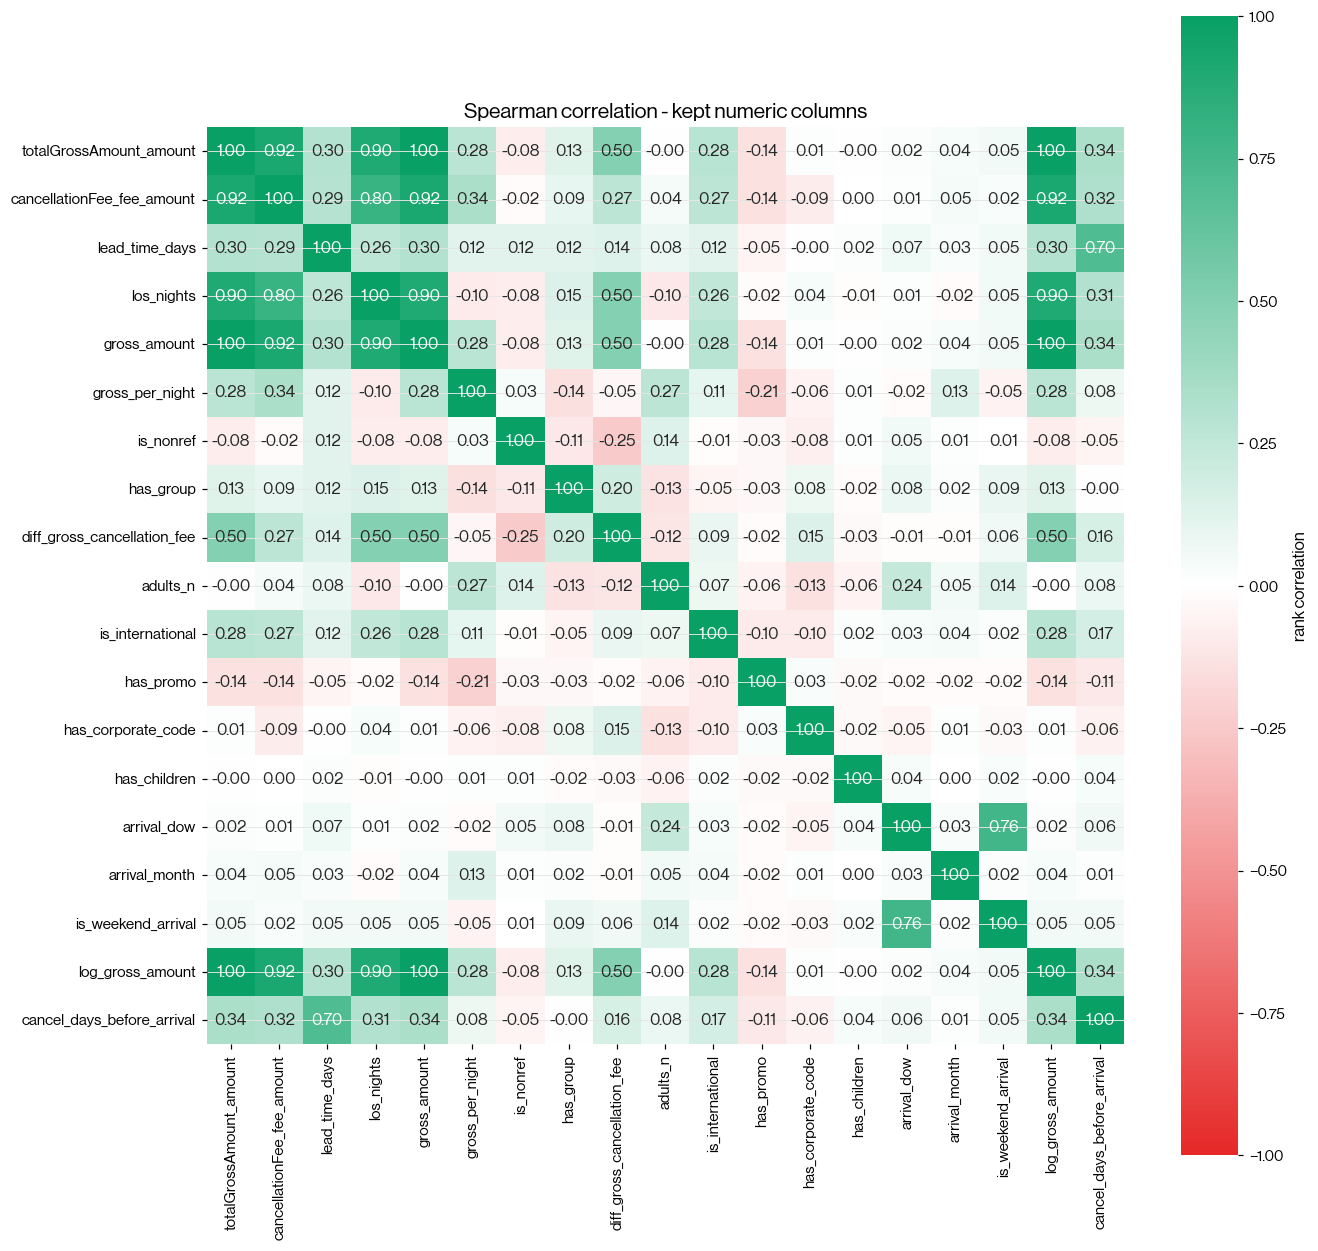


Highest |Spearman| pairs (top 15):
totalGrossAmount_amount      log_gross_amount               1.00
                             cancellationFee_fee_amount     0.92
los_nights                   gross_amount                   0.90
cancellationFee_fee_amount   los_nights                     0.80
arrival_dow                  is_weekend_arrival             0.76
lead_time_days               cancel_days_before_arrival     0.70
diff_gross_cancellation_fee  log_gross_amount               0.50
los_nights                   diff_gross_cancellation_fee    0.50
gross_per_night              cancellationFee_fee_amount     0.34
gross_amount                 cancel_days_before_arrival     0.34
cancel_days_before_arrival   cancellationFee_fee_amount     0.32
                             los_nights                     0.31
log_gross_amount             lead_time_days                 0.30
lead_time_days               cancellationFee_fee_amount     0.29
totalGrossAmount_amount      is_international         

,feature_a,feature_b,abs_spearman,note
0,totalGrossAmount_amount,log_gross_amount,1.000000,identical (engineered duplicate)
1,totalGrossAmount_amount,cancellationFee_fee_amount,0.920044,real collinearity - VIF check downstream
2,los_nights,gross_amount,0.899261,real collinearity - VIF check downstream


  > 3.6 inspected numeric correlations                        177,031 rows x  41 cols   (no change)


In [29]:
# `lead_time_days`, `los_nights`, `gross_amount`, `gross_per_night` were
# engineered in § 3.0 so they appear here alongside the raw numerics.
num_df = df.select_dtypes(include=["number"]).apply(pd.to_numeric, errors="coerce")
num_df = num_df.loc[:, num_df.nunique(dropna=True) > 1]
corr = num_df.corr(method="spearman", min_periods=50)

neg, neu, pos = diverging_triplet()
cmap = sns.blend_palette([neg, neu, pos], as_cmap=True)
fig, ax = plt.subplots(figsize=(0.55 * len(corr) + 3, 0.55 * len(corr) + 3))
sns.heatmap(corr, vmin=-1, vmax=1, cmap=cmap, annot=True, fmt=".2f",
            square=True, ax=ax, cbar_kws={"label": "rank correlation"})
ax.set_title("Spearman correlation - kept numeric columns")
fig.savefig(FIG_DIR / "05_correlation_heatmap.png"); plt.show()

stacked = (corr.where(~np.eye(len(corr), dtype=bool))
               .stack().abs().sort_values(ascending=False))
top_pairs = stacked.drop_duplicates().head(15).round(2)
print("\nHighest |Spearman| pairs (top 15):")
print(top_pairs)

# Save a CSV of high-correlation pairs so the modelling notebooks have a
# ready-made suspect list for VIF.
HIGH_CORR_THRESHOLD = 0.80
high = (stacked[stacked >= HIGH_CORR_THRESHOLD]
        .drop_duplicates()
        .rename("abs_spearman")
        .reset_index()
        .rename(columns={"level_0": "feature_a", "level_1": "feature_b"}))
high["note"] = high.apply(
    lambda r: ("identical (engineered duplicate)" if r["abs_spearman"] >= 0.999
               else "real collinearity - VIF check downstream"),
    axis=1,
)
high.to_csv(TBL_DIR / "high_corr_pairs.csv", index=False)
print(f"\n  high-correlation pairs (|ρ| ≥ {HIGH_CORR_THRESHOLD}) saved → "
      f"{TBL_DIR / 'high_corr_pairs.csv'}")
display(high)

prev = snap("3.6 inspected numeric correlations", df, prev=prev)


**§ 3.6 manual drop placeholder.** Decide which numeric columns to drop based on the heatmap, the top-pairs list, and the saved CSV. Empty list = no-op.


In [30]:
# § 3.6 - manual drops for numeric multicollinearity.
MANUAL_DROPS_NUMERIC_CORR: list[str] = [
   "totalGrossAmount_amount",
   "cancellationFee_fee_amount",
   "noShowFee_fee_amount"
]
apply_manual_drops(MANUAL_DROPS_NUMERIC_CORR,
                   reason="manual: numeric multicollinearity (§ 3.6)",
                   step="3.6")


  > 3.6 manual drops applied                                  177,031 rows x  38 cols   (-3 cols)
  dropped: ['totalGrossAmount_amount', 'cancellationFee_fee_amount', 'noShowFee_fee_amount']


### 3.6.5 - Numeric ↔ categorical association (correlation ratio η)

Spearman (§3.6) is numeric↔numeric and Cramér's V (§3.7) is categorical↔categorical. The **correlation ratio** η ∈ [0,1] does: the share of a numeric's variance explained by the grouping (η≈1 ⇒ the category determines the numeric → redundant). Used here to check whether `diff_gross_cancellation_fee` is already captured by the rate plan.

In [31]:
def correlation_ratio(cats: pd.Series, vals: pd.Series) -> float:
    """Eta: sqrt(SS_between / SS_total) for a numeric grouped by a category."""
    vals = pd.to_numeric(vals, errors="coerce")
    cats = cats.astype("string")
    m = cats.notna() & vals.notna()
    cats, vals = cats[m], vals[m]
    if cats.nunique() < 2 or len(vals) < 3:
        return np.nan
    grand = vals.mean()
    ss_total = float(((vals - grand) ** 2).sum())
    if ss_total == 0:
        return np.nan
    ss_between = float(sum(len(g) * (g.mean() - grand) ** 2
                          for _, g in vals.groupby(cats, observed=True)))
    return float(np.sqrt(ss_between / ss_total))

_num = [c for c in df.columns
        if pd.api.types.is_numeric_dtype(df[c]) and c not in {"status", "is_temporal_test"}]
_cat = [c for c in df.columns
        if (df[c].dtype == "string" or df[c].dtype == object)
        and 2 <= df[c].nunique(dropna=True) <= 60]
eta = pd.DataFrame({cat: {num: correlation_ratio(df[cat], df[num]) for num in _num}
                    for cat in _cat})
print("correlation ratio \u03b7  (rows = numeric, cols = categorical):")
display(eta.style.background_gradient(cmap="Reds", vmin=0, vmax=1).format("{:.2f}"))

# focused check: is diff_gross_cancellation_fee already explained by the rate plan?
for cc in ("ratePlan_type", "ratePlan_category"):
    if cc in df.columns and "diff_gross_cancellation_fee" in df.columns:
        print(f"  eta({cc} -> diff_gross_cancellation_fee) = "
              f"{correlation_ratio(df[cc], df['diff_gross_cancellation_fee']):.3f}")
if {"diff_gross_cancellation_fee", "ratePlan_type"}.issubset(df.columns):
    print("\n  diff_gross_cancellation_fee mean by ratePlan_type:")
    print(df.groupby("ratePlan_type", observed=True)["diff_gross_cancellation_fee"]
            .mean().round(1).to_string())

correlation ratio η  (rows = numeric, cols = categorical):


,status,travelPurpose,property_name,unitGroup_name,channelCode,primaryGuest_preferredLanguage,guaranteeType,cancellationFee_name,noShowFee_id,ratePlan_type,ratePlan_category,guest_country_region,stay_bucket
ratePlan_isSubjectToCityTax,0.04,0.11,0.79,0.18,0.26,0.11,0.33,0.35,0.79,0.14,0.53,0.12,0.12
hasCityTax,0.13,0.38,0.85,0.25,0.22,0.17,0.19,0.26,0.85,0.23,0.37,0.21,0.10
lead_time_days,0.19,0.10,0.18,0.03,0.10,0.09,0.05,0.16,0.18,0.06,0.15,0.13,0.16
los_nights,0.16,0.04,0.18,0.10,0.23,0.15,0.11,0.74,0.18,0.14,0.75,0.17,0.63
gross_amount,0.16,0.02,0.22,0.12,0.20,0.20,0.11,0.71,0.22,0.15,0.73,0.22,0.66
gross_per_night,0.06,0.07,0.34,0.23,0.19,0.11,0.06,0.34,0.34,0.27,0.38,0.14,0.19
is_nonref,0.20,0.12,0.17,0.05,0.24,0.03,0.99,0.99,0.17,1.00,1.00,0.14,0.18
has_group,0.07,0.21,0.17,0.09,0.59,0.06,0.12,0.39,0.17,0.11,0.25,0.09,0.22
diff_gross_cancellation_fee,0.14,0.04,0.15,0.10,0.21,0.13,0.11,0.67,0.15,0.13,0.69,0.15,0.54
adults_n,0.02,0.43,0.22,0.15,0.28,0.06,0.18,0.27,0.22,0.23,0.29,0.12,0.11


  eta(ratePlan_type -> diff_gross_cancellation_fee) = 0.126
  eta(ratePlan_category -> diff_gross_cancellation_fee) = 0.691

  diff_gross_cancellation_fee mean by ratePlan_type:
ratePlan_type
comp            0.7
corporate     128.1
flexible      226.3
nonref          5.7
other        1628.4
promo          59.1


### 3.7 - Categorical association (Cramér's V)


  categorical columns analysed (25): ['status', 'travelPurpose', 'property_name', 'ratePlan_isSubjectToCityTax', 'unitGroup_name', 'channelCode', 'primaryGuest_preferredLanguage', 'guaranteeType', 'cancellationFee_name', 'noShowFee_id', 'hasCityTax', 'is_nonref', 'ratePlan_type', 'ratePlan_category', 'has_group', 'adults_n', 'is_international', 'has_promo', 'has_corporate_code', 'has_children', 'guest_country_region', 'arrival_dow', 'arrival_month', 'is_weekend_arrival', 'stay_bucket']


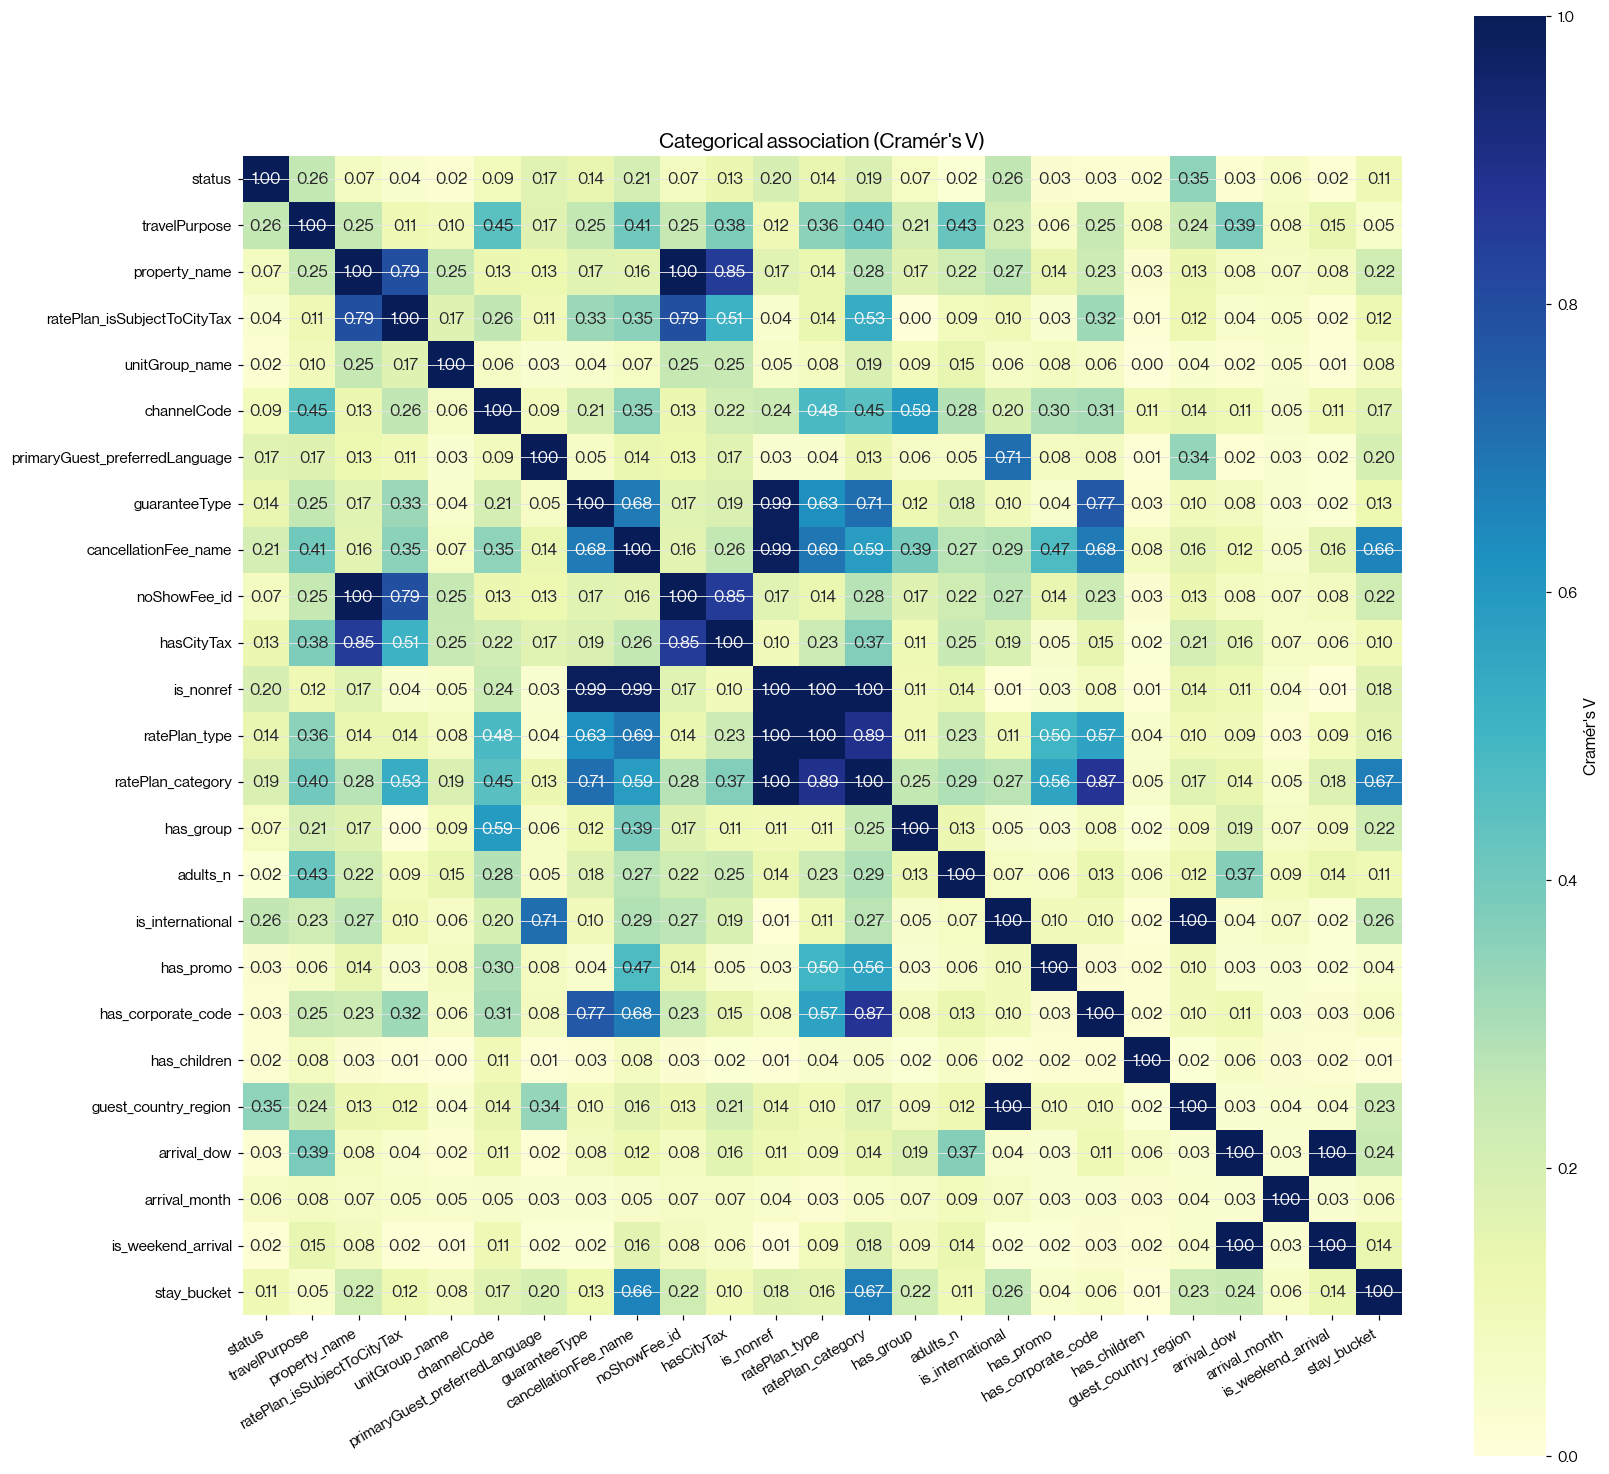


Highest Cramér's V pairs (top 15):
property_name         noShowFee_id                      1.00
is_nonref             ratePlan_type                     1.00
guest_country_region  is_international                  1.00
is_nonref             ratePlan_category                 1.00
cancellationFee_name  is_nonref                         0.99
guaranteeType         is_nonref                         0.99
ratePlan_category     ratePlan_type                     0.89
                      has_corporate_code                0.87
hasCityTax            noShowFee_id                      0.85
property_name         hasCityTax                        0.85
noShowFee_id          ratePlan_isSubjectToCityTax       0.79
has_corporate_code    guaranteeType                     0.77
guaranteeType         ratePlan_category                 0.71
is_international      primaryGuest_preferredLanguage    0.71
cancellationFee_name  ratePlan_type                     0.69
dtype: float64
  > 3.7 inspected categorical asso

In [32]:
def chi2_stat(table: pd.DataFrame) -> float:
    observed   = table.values.astype(float)
    row_totals = observed.sum(axis=1, keepdims=True)
    col_totals = observed.sum(axis=0, keepdims=True)
    grand      = observed.sum()
    if grand == 0:
        return 0.0
    expected = row_totals @ col_totals / grand
    with np.errstate(divide="ignore", invalid="ignore"):
        chi2 = np.where(expected > 0, (observed - expected) ** 2 / expected, 0).sum()
    return float(chi2)


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    table = pd.crosstab(x, y)
    if table.size == 0:
        return float("nan")
    chi2 = chi2_stat(table)
    n = table.values.sum()
    if n == 0:
        return float("nan")
    phi2 = chi2 / n
    r, k = table.shape
    phi2corr = max(0.0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - (r - 1) ** 2 / (n - 1)
    kcorr = k - (k - 1) ** 2 / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return float(np.sqrt(phi2corr / denom)) if denom > 0 else float("nan")


DATETIME_LIKE = ("arrival", "departure", "created", "modified")
cat_candidates = []
for c in df.columns:
    if c in DATETIME_LIKE:
        continue
    s = df[c]
    nunique = int(s.nunique(dropna=True))
    if 2 <= nunique <= 50 and s.notna().mean() >= 0.5:
        cat_candidates.append(c)

print(f"  categorical columns analysed ({len(cat_candidates)}): {cat_candidates}")
assert cat_candidates, "Cramér's V still has no categorical columns - something is off with df"

cv = pd.DataFrame(index=cat_candidates, columns=cat_candidates, dtype=float)
for a in cat_candidates:
    for b in cat_candidates:
        if a == b:
            cv.loc[a, b] = 1.0
        elif not pd.isna(cv.loc[b, a]):
            cv.loc[a, b] = cv.loc[b, a]
        else:
            cv.loc[a, b] = cramers_v(df[a].astype("string"), df[b].astype("string"))

fig, ax = plt.subplots(figsize=(0.6 * len(cv) + 2, 0.6 * len(cv) + 2))
sns.heatmap(cv.astype(float), vmin=0, vmax=1, cmap="YlGnBu", annot=True,
            fmt=".2f", square=True, ax=ax, cbar_kws={"label": "Cramér's V"})
ax.set_title("Categorical association (Cramér's V)")
plt.xticks(rotation=30, ha="right")
fig.savefig(FIG_DIR / "06_cramers_v.png"); plt.show()

# Print the top off-diagonal pairs so we don't miss subtle duplications.
mask = ~np.eye(len(cv), dtype=bool)
pairs = (cv.where(mask).stack().sort_values(ascending=False)
           .drop_duplicates().head(15).round(2))
print("\nHighest Cramér's V pairs (top 15):")
print(pairs)

prev = snap("3.7 inspected categorical associations", df, prev=prev)


**§ 3.7 manual drop placeholder.** Decide which categorical columns to drop based on the Cramér's V heatmap and the top-pairs list. Empty list = no-op.


In [33]:
# § 3.7 - manual drops for categorical multicollinearity.
MANUAL_DROPS_CATEGORICAL: list[str] = [
    "noShowFee_id",
    "is_nonref",
    "ratePlan_isSubjectToCityTax",
    "hasCityTax",
    "is_international"
]
apply_manual_drops(MANUAL_DROPS_CATEGORICAL,
                   reason="manual: categorical multicollinearity (§ 3.7)",
                   step="3.7")


  > 3.7 manual drops applied                                  177,031 rows x  33 cols   (-5 cols)
  dropped: ['noShowFee_id', 'is_nonref', 'ratePlan_isSubjectToCityTax', 'hasCityTax', 'is_international']


## 4 - Row-level cleaning (iterative, one rule at a time)

### 4.1 - Drop duplicates


Two tiers of duplicate:

- **Exact duplicates** on the booking `id` - these should be impossible by source-system contract, but we check.
- **Soft duplicates** on `(property_code, arrival, departure, gross_amount)` - usually
  the same booking re-issued under a new `id` due to a system migration. We
  keep the first occurrence (the original).


In [34]:
n_before = len(df)
n_id_dup = int(df.duplicated(subset=["id"]).sum()) if "id" in df.columns else 0
print(f"  duplicate booking IDs: {n_id_dup:,}")
if n_id_dup:
    df = df.drop_duplicates(subset=["id"], keep="first").copy()

soft_cols = [c for c in ["property_name", "arrival", "departure", "gross_amount"]
             if c in df.columns]
n_soft_dup = int(df.duplicated(subset=soft_cols, keep="first").sum())
print(f"  soft duplicates (property+arrival+departure+gross): {n_soft_dup:,}")
if n_soft_dup:
    print("    not dropping soft duplicates (legitimate multi-row bookings may match this key).")

# `id` was kept past §3.5 only so this dedup could run; drop the opaque ID now.
if "id" in df.columns:
    df = df.drop(columns=["id"])
    record_drop(["id"], "opaque ID (kept only for the §4.1 dedup)", "4.1")

prev = snap("4.1 dropped exact-ID duplicates", df, prev=prev)


  duplicate booking IDs: 0
  soft duplicates (property+arrival+departure+gross): 30,937
    not dropping soft duplicates (legitimate multi-row bookings may match this key).
  > 4.1 dropped exact-ID duplicates                           177,031 rows x  32 cols   (-1 cols)


### 4.2 - Fix lead_time < 0 (clip to zero, do not drop)


A negative lead time means `created > arrival`, which usually reflects a timezone artefact (booking placed minutes before midnight UTC for a same-day stay in CET). We treat these as same-day bookings by clipping `lead_time` to 0


In [35]:
arrival   = pd.to_datetime(df["arrival"],   utc=True)
created   = pd.to_datetime(df["created"],   utc=True)
lead      = (arrival - created) / pd.Timedelta(days=1)
mask_neg  = (lead < 0).fillna(False)
n_fixed   = int(mask_neg.sum())
df.loc[mask_neg, "created"] = arrival[mask_neg]
print(f"  clipped {n_fixed:,} rows where lead_time was negative (created := arrival).")

# Refresh the engineered derivative whose input we just mutated.
df["lead_time_days"] = (arrival - pd.to_datetime(df["created"], utc=True)) / pd.Timedelta(days=1)
print("  refreshed lead_time_days (stale after the clip above).")
prev = snap("4.2 clipped negative lead_time", df, prev=prev)


  clipped 6,119 rows where lead_time was negative (created := arrival).
  refreshed lead_time_days (stale after the clip above).
  > 4.2 clipped negative lead_time                            177,031 rows x  32 cols   (no change)


### 4.3 - Drop data errors and outliers


Each rule is applied separately so we can see what it removes.

1. `lead_time_days > 365` - drop. Booking placed > 14 months before arrival is almost always a pipeline error.
2. `los_nights < 1` - drop. Same calendar day for arrival AND departure is impossible.
3. `status == Canceled` AND `gross_amount <= 0` - **keep**, set `gross_amount` to NaN. Post-refund zeroing, not a true price.
4. `status != Canceled` AND `gross_amount <= 0` - drop. Zero/negative gross on a CheckedOut/InHouse booking is staff comp or pipeline error.
5. `los_nights > 200` - drop. Hard cap; stays > 200 nights are old extended-stay contracts (different business case).
6. `gross_per_night > mean + 3.5σ` - drop. Extreme-tail per-night rate (suite/penthouse territory) - rare and unstable signal.


In [36]:
# === §4.3.a - Diagnostic snapshot of every numeric column ====================
df["_los_nights"] = (
    (pd.to_datetime(df["departure"], utc=True).dt.normalize()
   - pd.to_datetime(df["arrival"],   utc=True).dt.normalize())
    / pd.Timedelta(days=1)
).astype("Float64")
df["_lead_time"] = (
    (pd.to_datetime(df["arrival"], utc=True)
   - pd.to_datetime(df["created"], utc=True))
    / pd.Timedelta(days=1)
).astype("Float64")
df["_gross"]     = pd.to_numeric(df["gross_amount"], errors="coerce")
df["_gpn"]       = df["_gross"] / df["_los_nights"].replace(0, pd.NA)

def numeric_diag(frame: pd.DataFrame, *, min_unique: int = 5) -> pd.DataFrame:
    """Per-column summary; skips binary/near-constant numerics."""
    rows = []
    for col in frame.select_dtypes(include="number").columns:
        s = pd.to_numeric(frame[col], errors="coerce")
        v = s.dropna()
        if v.empty or v.nunique() < min_unique:
            continue
        q1, q3 = v.quantile([0.25, 0.75])
        iqr    = q3 - q1
        lo_iqr, hi_iqr = q1 - 1.5*iqr, q3 + 1.5*iqr
        mu, sd = v.mean(), v.std()
        lo_3s, hi_3s = mu - 3*sd, mu + 3*sd
        p01, p99 = v.quantile([0.01, 0.99])
        rows.append({
            "column":         col,
            "n":              len(v),
            "n_miss":         int(s.isna().sum()),
            "mean":           mu,
            "std":            sd,
            "min":            v.min(),
            "p1":             p01,
            "p25":            q1,
            "p50":            v.median(),
            "p75":            q3,
            "p99":            p99,
            "max":            v.max(),
            "skew":           v.skew(),
            "n_out_iqr1.5":   int(((v < lo_iqr) | (v > hi_iqr)).sum()),
            "n_out_3sigma":   int(((v < lo_3s)  | (v > hi_3s )).sum()),
            "n_out_p1_p99":   int(((v < p01)    | (v > p99   )).sum()),
        })
    return pd.DataFrame(rows).set_index("column").sort_values("skew", ascending=False)

diag = numeric_diag(df)
print(f"  scanned {len(diag)} non-binary numeric columns over {len(df):,} rows")
print(f"  sorted by skew (heavy-tail candidates at top)\n")
display(
    diag.style.format({
        "mean": "{:.1f}", "std": "{:.1f}", "min": "{:.1f}",
        "p1": "{:.1f}",   "p25": "{:.1f}", "p50": "{:.1f}",
        "p75": "{:.1f}",  "p99": "{:.1f}", "max": "{:.1f}",
        "skew": "{:.2f}",
        "n_out_iqr1.5": "{:,}", "n_out_3sigma": "{:,}", "n_out_p1_p99": "{:,}",
    }).background_gradient(cmap="YlOrRd",
                           subset=["skew", "n_out_iqr1.5", "n_out_3sigma", "n_out_p1_p99"])
)

  scanned 13 non-binary numeric columns over 177,031 rows
  sorted by skew (heavy-tail candidates at top)



,n,n_miss,mean,std,min,p1,p25,p50,p75,p99,max,skew,n_out_iqr1.5,n_out_3sigma,n_out_p1_p99
column,,,,,,,,,,,,,,,
diff_gross_cancellation_fee,177031,0,172.2,718.1,0.0,0.0,0.0,0.0,28.0,3103.0,21251.0,9.62,"35,084","2,623","1,771"
los_nights,177031,0,4.6,11.6,0.0,1.0,1.0,2.0,3.0,57.0,304.0,8.19,"22,042","2,699","1,739"
_los_nights,177031,0,4.6,11.6,0.0,1.0,1.0,2.0,3.0,57.0,304.0,8.19,"22,042","2,699","1,739"
gross_amount,177031,0,406.3,804.4,0.0,15.0,99.9,178.0,367.0,3599.3,21720.0,7.75,"19,148","2,839","3,540"
_gross,177031,0,406.3,804.4,0.0,15.0,99.9,178.0,367.0,3599.3,21720.0,7.75,"19,148","2,839","3,540"
cancel_days_before_arrival,36964,140067,19.2,32.6,-114.0,-0.7,1.2,6.1,22.7,160.3,364.0,3.34,"3,615",853,740
lead_time_days,177031,0,25.6,38.5,0.0,0.0,2.7,11.0,32.0,191.0,490.3,3.04,"15,429","4,026","1,771"
_lead_time,177031,0,25.6,38.5,0.0,0.0,2.7,11.0,32.0,191.0,490.3,3.04,"15,429","4,026","1,771"
gross_per_night,177028,3,106.4,42.9,0.0,12.0,80.1,98.7,122.0,259.0,896.2,2.61,"9,795","2,715","3,512"


In [37]:
# === §4.3.b - Per-column inspector ==========================================
def inspect(col: str, *, log_x: bool = False) -> None:
    """Distribution + cut-impact table for ONE numeric column. Apply nothing."""
    s = pd.to_numeric(df[col], errors="coerce")
    v = s.dropna()
    if v.empty:
        print(f"  {col}: all-NaN, skipping")
        return

    print(f"  === {col} ===")
    print(f"    n = {len(v):,}   n_missing = {int(s.isna().sum()):,}")
    print(f"    range:  {v.min():>10.2f}  ..  {v.max():>10.2f}")
    print(f"    mean ± sd:   {v.mean():.2f} ± {v.std():.2f}")
    print(f"    median:      {v.median():.2f}")
    print(f"    skew:        {v.skew():.3f}    kurt: {v.kurtosis():.3f}\n")

    # Cut-impact table - what would each rule remove?
    q1, q3 = v.quantile([0.25, 0.75]); iqr = q3 - q1
    mu, sd = v.mean(), v.std()
    cuts = [
        ("IQR x1.5",   q1 - 1.5*iqr,  q3 + 1.5*iqr),
        ("IQR x3.0",   q1 - 3.0*iqr,  q3 + 3.0*iqr),
        ("3 sigma",    mu - 3*sd,     mu + 3*sd),
        ("3.5 sigma",  mu - 3.5*sd,   mu + 3.5*sd),
        ("p1 / p99",   v.quantile(0.01), v.quantile(0.99)),
        ("p0.5/p99.5", v.quantile(0.005), v.quantile(0.995)),
    ]
    table = []
    for name, lo, hi in cuts:
        n_lo, n_hi = int((v < lo).sum()), int((v > hi).sum())
        table.append({"rule": name, "lower": lo, "upper": hi,
                      "n_below": n_lo, "n_above": n_hi,
                      "n_drop_total": n_lo + n_hi,
                      "share_drop":   (n_lo + n_hi) / len(v)})
    display(pd.DataFrame(table).set_index("rule").style.format({
        "lower": "{:.1f}", "upper": "{:.1f}",
        "n_below": "{:,}", "n_above": "{:,}", "n_drop_total": "{:,}",
        "share_drop": "{:.2%}",
    }))

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    axes[0].hist(v, bins=80, color=color("blue"), alpha=0.85)
    if log_x: axes[0].set_xscale("log")
    axes[0].set_title(f"{col} - histogram"); axes[0].set_xlabel(col)
    axes[1].boxplot(v, vert=False)
    axes[1].set_title(f"{col} - boxplot");  axes[1].set_xlabel(col)
    plt.tight_layout(); plt.show()

# Run for each column you flagged in §4.5.a. log_x=True hilft bei sehr schiefen distributions
#inspect("_lead_time")
#inspect("_los_nights")
#inspect("_gross", log_x=True)

In [38]:
# === §4.3.c - Apply rules (one at a time, with rationale + audit) ============

def apply_rule(label: str, keep_mask: pd.Series, rationale: str) -> int:
    """One rule, one drop count, one audit log entry."""
    global df, prev
    keep_mask = keep_mask.fillna(False)
    n_before = len(df)
    df = df[keep_mask].copy()
    n_drop = n_before - len(df)
    print(f"  ▸ {label}")
    print(f"      rationale : {rationale}")
    print(f"      kept      : {keep_mask.sum():>8,}")
    print(f"      dropped   : {n_drop:>8,}  ({n_drop/n_before:.2%} of pre-rule df)\n")
    prev = snap(f"4.3 after {label}", df, prev=prev, dropped_cols=[])
    return n_drop


In [39]:
# --- Rule 1: lead_time > 365 ------------------------------------------------
lead = df["_lead_time"]
apply_rule(
    "lead_time_days > 365",
    lead <= 365,
    "Booking placed >14 months before arrival is almost always a pipeline error.",
)


  ▸ lead_time_days > 365
      rationale : Booking placed >14 months before arrival is almost always a pipeline error.
      kept      :  177,020
      dropped   :       11  (0.01% of pre-rule df)

  > 4.3 after lead_time_days > 365                            177,020 rows x  36 cols   (--4 cols, -11 rows)


11

In [40]:

# --- Rule 2: los_nights < 1 (same calendar day) -----------------------------
los = df["_los_nights"]
apply_rule(
    "los_nights < 1 (same calendar day)",
    los >= 1,
    "Arrival.date() == departure.date() means zero-night stay - impossible.",)


  ▸ los_nights < 1 (same calendar day)
      rationale : Arrival.date() == departure.date() means zero-night stay - impossible.
      kept      :  177,017
      dropped   :        3  (0.00% of pre-rule df)

  > 4.3 after los_nights < 1 (same calendar day)              177,017 rows x  36 cols   (-3 rows)


3

In [41]:
# --- Rule 3: Canceled + gross<=0 -> drop (post-refund zeroing) ---------------
gross     = pd.to_numeric(df["gross_amount"], errors="coerce")
is_cancel = (df["status"] == "Canceled")
apply_rule(
    "Canceled + gross_amount<=0 (post-refund zeroing -> drop)",
    ~(is_cancel & gross.le(0).fillna(False)),
    "Price overwritten post-cancellation; booking-time value lost. Symmetric with Rule 4.",
)


  ▸ Canceled + gross_amount<=0 (post-refund zeroing -> drop)
      rationale : Price overwritten post-cancellation; booking-time value lost. Symmetric with Rule 4.
      kept      :  176,636
      dropped   :      381  (0.22% of pre-rule df)

  > 4.3 after Canceled + gross_amount<=0 (post-refund zeroing -> drop)   176,636 rows x  36 cols   (-381 rows)


381

In [42]:
# Non-cancelled + gross <= 0 = staff comp / pipeline error. Drop.
gross     = pd.to_numeric(df["gross_amount"], errors="coerce")
is_cancel = (df["status"] == "Canceled")
apply_rule(
    "non-Canceled + gross_amount<=0",
    ~(gross.le(0).fillna(False) & ~is_cancel),
    "Zero/negative gross on a CheckedOut/InHouse booking is staff comp or error.",
)


  ▸ non-Canceled + gross_amount<=0
      rationale : Zero/negative gross on a CheckedOut/InHouse booking is staff comp or error.
      kept      :  175,271
      dropped   :    1,365  (0.77% of pre-rule df)

  > 4.3 after non-Canceled + gross_amount<=0                  175,271 rows x  36 cols   (-1,365 rows)


1365

In [43]:
# --- Rule 4: los_nights > 200 -----------------------------------------------
df["_los_nights"] = (
    (pd.to_datetime(df["departure"], utc=True).dt.normalize()
   - pd.to_datetime(df["arrival"],   utc=True).dt.normalize())
    / pd.Timedelta(days=1)
).astype("Float64")
LOS_CAP = 200
apply_rule(
    f"los_nights > {LOS_CAP}",
    df["_los_nights"] <= LOS_CAP,
    f"Stays longer than {LOS_CAP} nights old extended-stay contracts, "
    f"different business case.",
)

  ▸ los_nights > 200
      rationale : Stays longer than 200 nights old extended-stay contracts, different business case.
      kept      :  175,252
      dropped   :       19  (0.01% of pre-rule df)

  > 4.3 after los_nights > 200                                175,252 rows x  36 cols   (-19 rows)


19

In [44]:
# --- Rule 5: gross_per_night outlier cap ( median + k*MAD) -----------
df["_gpn"] = (pd.to_numeric(df["gross_amount"], errors="coerce")
              / df["_los_nights"].replace(0, pd.NA))
GPN_K    = 7
_arr     = pd.to_datetime(df["arrival"], utc=True)
# Train proxy CONSISTENT with the §7 production split (arrival < ASOF - 2*H, H=14);
# leak-free and the SAME train population as the models (not oldest-60%-by-arrival).
_train_m = _arr < (_arr.max() - pd.Timedelta(days=28))
_gpn_tr  = df.loc[_train_m, "_gpn"]
gpn_med  = float(_gpn_tr.median())
gpn_mad  = float((_gpn_tr - gpn_med).abs().median()) * 1.4826   # ~ robust sigma
gpn_cap  = gpn_med + GPN_K * gpn_mad
apply_rule(
    f"gross_per_night > median + {GPN_K}*MAD (cap={gpn_cap:.1f})",
    df["_gpn"] <= gpn_cap,
    f"Per-night > {gpn_cap:.0f}EUR (median={gpn_med:.1f} + {GPN_K}*robust_sd={gpn_mad:.1f}) "
    f"is suite/penthouse territory - rare, unstable signal. MAD-based so the cap "
    f"is not inflated by the outliers themselves.",
)

  ▸ gross_per_night > median + 7*MAD (cap=306.6)
      rationale : Per-night > 307EUR (median=99.0 + 7*robust_sd=29.7) is suite/penthouse territory - rare, unstable signal. MAD-based so the cap is not inflated by the outliers themselves.
      kept      :  174,482
      dropped   :      770  (0.44% of pre-rule df)

  > 4.3 after gross_per_night > median + 7*MAD (cap=306.6)    174,482 rows x  36 cols   (-770 rows)


770

#### 4.3.d - Clean up diagnostic scratch columns


In [45]:
# Remove the underscore-prefixed columns used only by the §4.3 diagnostic /
# inspector helpers. Keeping them on `df` would dump them into the final parquet.
diag_cols = [c for c in ("_los_nights", "_lead_time", "_gross", "_gpn") if c in df.columns]
if diag_cols:
    df = df.drop(columns=diag_cols)
    print(f"  removed scratch columns: {diag_cols}")
else:
    print("  no scratch columns to remove.")
prev = snap("4.3.d removed diagnostic scratch cols", df, prev=prev)


  removed scratch columns: ['_los_nights', '_lead_time', '_gross', '_gpn']
  > 4.3.d removed diagnostic scratch cols                     174,482 rows x  32 cols   (-4 cols)


### 4.4 - Drop tiny properties (<50 rows)

**New-hotel path:** the `<50`-row are dropped for a clean per-property one-hot signal. Recently-opened hotels are therefore excluded from *training*, but remain fully **scoreable** - the model's OneHotEncoder uses `handle_unknown="ignore"`,
so an unseen/new property simply gets no property-specific dummy and is predicted from its other features (lead time, rate plan, region, channel, ...).

In [46]:
MIN_ROWS_PER_PROPERTY = 50
counts = df.groupby("property_name").size().sort_values()
small = counts[counts < MIN_ROWS_PER_PROPERTY].index.tolist()
n_before = len(df)
if small:
    df = df[~df["property_name"].isin(small)].copy()
    print(f"  dropped tiny properties ({len(small)}): {small}")
else:
    print("  no tiny properties - nothing to drop.")
prev = snap("4.4 dropped tiny properties", df, prev=prev)


  no tiny properties - nothing to drop.
  > 4.4 dropped tiny properties                               174,482 rows x  32 cols   (no change)


### 4.5 - Final data-quality QC


Sanity-check the cleaned frame. These assertions MUST pass for the modelling notebooks to behave; we make the failure noisy on purpose.


In [47]:
qc_failures = []

TARGET_STATUSES = {"Canceled", "CheckedOut", "InHouse"}
bad_status = df[~df["status"].isin(TARGET_STATUSES)]
if len(bad_status):
    qc_failures.append(f"{len(bad_status)} rows in non-target status")

if (df["arrival"] >= ARRIVAL_CUTOFF).any():
    qc_failures.append("future arrivals still present")
if (df["arrival"] < ARRIVAL_FLOOR).any():
    qc_failures.append("pre-floor (COVID-era) arrivals still present")

arrival = pd.to_datetime(df["arrival"], utc=True)
created = pd.to_datetime(df["created"], utc=True)
if ((arrival - created) / pd.Timedelta(days=1) < 0).any():
    qc_failures.append("negative lead_time still present")

departure = pd.to_datetime(df["departure"], utc=True)
los = ((departure.dt.normalize() - arrival.dt.normalize())
       / pd.Timedelta(days=1)).astype("Float64")
if (los < 1).any():
    qc_failures.append("los < 1 still present")

if df.isna().all(axis=1).any():
    qc_failures.append("fully-empty rows present")

if "property_name" not in df.columns or df["property_name"].isna().any():
    qc_failures.append("property_name missing or has NaN")

if qc_failures:
    raise AssertionError("QC failed:\n  - " + "\n  - ".join(qc_failures))
print(f"  all QC checks passed. final: {len(df):,} rows x {df.shape[1]} cols")
prev = snap("4.5 QC passed", df, prev=prev)

# --- Binary target encoding (Canceled=1, CheckedOut/InHouse=0) ---------
STATUS_MAP = {"Canceled": 1, "CheckedOut": 0, "InHouse": 0}
unmapped = set(df["status"].unique()) - set(STATUS_MAP)
assert not unmapped, f"unmapped statuses present: {unmapped}"
df["status"] = df["status"].map(STATUS_MAP).astype("int8")
print(f"  status encoded as int8 (1=Canceled, 0=CheckedOut/InHouse). "
      f"positive share: {df['status'].mean():.2%}")


  all QC checks passed. final: 174,482 rows x 32 cols
  > 4.5 QC passed                                             174,482 rows x  32 cols   (no change)
  status encoded as int8 (1=Canceled, 0=CheckedOut/InHouse). positive share: 20.79%


## 5 - Feature engineering

### 5.1 - Conditional imputation (group-mode, no target leakage)


One remaining column with meaningful missingness benefits from group-mode imputation against a feature that is **independent of the target**:

- `primaryGuest_preferredLanguage` -> impute by `primaryGuest_address_countryCode`

In [48]:
def impute_conditional(frame: pd.DataFrame, target_col: str, group_col: str) -> pd.Series:
    if target_col not in frame.columns or group_col not in frame.columns:
        return frame[target_col] if target_col in frame.columns else None
    global_mode = (frame[target_col].mode(dropna=True).iloc[0]
                   if frame[target_col].notna().any() else None)

    def fill_group(s: pd.Series) -> pd.Series:
        if s.isna().all():
            return s.fillna(global_mode)
        m = s.mode(dropna=True)
        return s.fillna(m.iloc[0] if not m.empty else global_mode)

    return frame.groupby(group_col, group_keys=False)[target_col].apply(fill_group)


if "primaryGuest_preferredLanguage" in df.columns:
    df["primaryGuest_preferredLanguage"] = impute_conditional(
        df, "primaryGuest_preferredLanguage", "primaryGuest_address_countryCode")
    print("  conditional imputation: preferredLanguage <- countryCode")
else:
    print("  preferredLanguage already absent; nothing to impute.")


  conditional imputation: preferredLanguage <- countryCode


### 5.2 - Company booking history

In [49]:
df["created"] = pd.to_datetime(df["created"], utc=True)
df["has_company"] = (df["company_name_clean"].astype("string").fillna("").str.strip()
                     .str.len() > 0).astype("Int64")

# Time-ordered cumulative counts per company (sum in int64 to avoid int8 overflow
# on large corporate accounts). cumcount/cumsum exclude the current row.
_d  = df.sort_values("created", kind="mergesort")
_c  = _d["company_name_clean"].astype("string")
_ne = _c.fillna("").str.strip().str.len() > 0
_y  = _d["status"].astype("int64")
prior_bk = _d.groupby(_c, observed=True).cumcount().where(_ne, 0)
prior_cx = (_y.groupby(_c, observed=True).cumsum() - _y).where(_ne, 0)
rate     = prior_cx / prior_bk.replace(0, np.nan)

df["company_prior_bookings"]    = prior_bk.reindex(df.index).astype("Int64")
df["company_prior_cancel_rate"] = rate.reindex(df.index).astype("Float64")
df["is_repeat_company"]         = (df["company_prior_bookings"] > 0).astype("Int64")

prev = snap("5.2 company history features", df, prev=prev)
print(f"  has_company={df['has_company'].mean():.1%}  "
      f"is_repeat={df['is_repeat_company'].mean():.1%}  "
      f"prior_cancel_rate present={df['company_prior_cancel_rate'].notna().mean():.1%}")

  > 5.2 company history features                              174,482 rows x  36 cols   (--4 cols)
  has_company=31.7%  is_repeat=24.8%  prior_cancel_rate present=24.8%


## 6 - Class imbalance - final share & strategy plan


In [50]:
positive_share = (df["status"] == 1).mean()
print(f"  positive class share: {positive_share:.2%}")
print(f"  total rows         : {len(df):,}")
print(f"  positive (1) / negative (0): {(df['status']==1).sum():,} / "
      f"{(df['status']==0).sum():,}  (InHouse merged into the negative class)")

if positive_share < 0.05:
    rec = "SEVERE imbalance - class_weight + probability calibration."
elif positive_share < 0.20:
    rec = "Moderate imbalance - class_weight='balanced' first, then calibrate."
else:
    rec = "Mild imbalance - start with no resampling, then compare."
print(f"  -> {rec}")

print("""
Strategy plan for the modelling notebooks (01-04):
  - Strategy A: baseline (no resampling, default class weights).
  - Strategy B: class_weight='balanced' (re-weight the loss), PAIRED WITH
                probability calibration (CalibratedClassifierCV) so the
                predicted p_cancel stays usable for the overbooking math.
  SMOTE is intentionally NOT used: at ~22% positive the imbalance is mild, and
  SMOTE interpolates one-hot category dummies into fractional values that match
  no real booking, hurting calibration without improving ranking.
Each model notebook reports PR-AUC and precision/recall at the operating point
chosen by §7 thresholding.
""")


  positive class share: 20.79%
  total rows         : 174,482
  positive (1) / negative (0): 36,276 / 138,206  (InHouse merged into the negative class)
  -> Mild imbalance - start with no resampling, then compare.

Strategy plan for the modelling notebooks (01-04):
  - Strategy A: baseline (no resampling, default class weights).
  - Strategy B: class_weight='balanced' (re-weight the loss), PAIRED WITH
                probability calibration (CalibratedClassifierCV) so the
                predicted p_cancel stays usable for the overbooking math.
  SMOTE is intentionally NOT used: at ~22% positive the imbalance is mild, and
  SMOTE interpolates one-hot category dummies into fractional values that match
  no real booking, hurting calibration without improving ranking.
Each model notebook reports PR-AUC and precision/recall at the operating point
chosen by §7 thresholding.



## 7 - Temporal split (point-in-time, no future-label leakage)

Split by two calendar cutoffs so that **every training label is resolved before
any later split's bookings are even made**: `train = arrival < T1`,
`val = created >= T1 & arrival < T2`, `test = created >= T2`. Bookings still
*open* across a cutoff go to an **`embargo`** bucket (kept in the parquet,
excluded from modelling). This is stricter than a plain `created`-split: it also
removes the residual "train label resolves slightly after the cutoff" leak, at
the cost of ~5% embargoed in-flight rows. The model notebooks select
`temporal_split in {train, val, test}` and never see `embargo`.

In [51]:
# =============================================================================
# §7 TEMPORAL SPLIT — PRODUCTION-FAITHFUL, arrival-anchored, point-in-time (v11)
# =============================================================================
# Production: jeden Tag scoren wir die Buchungen, die in den naechsten H Tagen ANREISEN,
# as-of "heute". Das bilden wir STATISCH ab, damit 01/02/03 EINEN vergleichbaren
# train/val/test teilen. Das rollende Pendant lebt in src.walkforward (gleiches Primitiv).
# "now" fuers TRAINING = juengstes Datensignal (max arrival), NICHT wall-clock.
#   train : outcome_known_date <= S_val      # ALLE bis S_val resolved (LONG-LEAD BLEIBT DRIN)
#   val   : aktiv@S_val,  arrival in (S_val,  S_val+H]
#   test  : aktiv@S_test, arrival in (S_test, S_test+H]   (juengstes Production-Fenster)
# aktiv@S = created<=S AND arrival>S AND outcome_known_date>S (bei S noch nicht resolved).
from src import walkforward as wf
df = wf.add_outcome_known_date(df)      # outcome_known_date: cancellationTime (pre-arr cancel) sonst arrival

H      = 14                              # Production-Horizont (Tage zukuenftiger Anreisen)
_arr   = pd.to_datetime(df["arrival"], utc=True)
_cre   = pd.to_datetime(df["created"], utc=True)
_known = pd.to_datetime(df["outcome_known_date"], utc=True)
ASOF   = _arr.max()                      # juengste resolved Anreise (data-derived "now")
S_test = ASOF - pd.Timedelta(days=H)
S_val  = S_test - pd.Timedelta(days=H)
_H     = pd.Timedelta(days=H)

is_test  = (_cre <= S_test) & (_arr > S_test) & (_arr <= S_test + _H) & (_known > S_test) & (_known <= ASOF)
is_val   = (_cre <= S_val)  & (_arr > S_val)  & (_arr <= S_val + _H)  & (_known > S_val)  & (_known <= S_test)
is_train = _known <= S_val
split = np.select([is_test, is_val, is_train], ["test", "val", "train"], default="unused")
df["temporal_split"]   = pd.Series(split, index=df.index, dtype="string")
df["is_temporal_test"] = (df["temporal_split"] == "test").astype("int8")
df["is_temporal_val"]  = (df["temporal_split"] == "val").astype("int8")

# Fail-loud point-in-time Invarianten (kein Future-Label-Leak):
assert _known[df["temporal_split"] == "train"].max() <= S_val, "train label known after S_val"
assert _cre[df["temporal_split"] == "test"].max() <= S_test, "test created after S_test"
assert _arr[df["temporal_split"] == "test"].min() > S_test, "test arrival on/before S_test"
assert (df["temporal_split"] == "test").sum() and (df["temporal_split"] == "val").sum(), "empty val/test"
print(f"  PRODUCTION SPLIT (arrival-anchored) | H={H}d  ASOF={ASOF.date()}  S_val={S_val.date()}  S_test={S_test.date()}")
print("  sizes:", df["temporal_split"].value_counts().to_dict())
for _nm in ["train", "val", "test"]:
    _m = df["temporal_split"] == _nm
    _lead = ((_arr - _cre) / pd.Timedelta(days=1))[_m]
    print(f"    {_nm:5s} n={int(_m.sum()):>7,} pos={df.loc[_m, 'status'].mean():.3f} lead_med={_lead.median():.0f}d")
prev = snap("7 production temporal split (arrival-anchored, long-lead kept)", df, prev=prev)


  PRODUCTION SPLIT (arrival-anchored) | H=14d  ASOF=2026-06-19  S_val=2026-05-22  S_test=2026-06-05
  sizes: {'train': 168066, 'unused': 3029, 'test': 1997, 'val': 1390}
    train n=168,066 pos=0.211 lead_med=11d
    val   n=  1,390 pos=0.087 lead_med=22d
    test  n=  1,997 pos=0.089 lead_med=24d
  > 7 production temporal split (arrival-anchored, long-lead kept)   174,482 rows x  40 cols   (--4 cols)


## §4.3 Log-transformed numeric columns

Skew-damped `log1p` versions of `diff_gross_cancellation_fee`, `los_nights`, `lead_time_days`, `gross_per_night` (created before the feature roster so they enter as numeric features). Idempotent.

In [52]:
# §4.3 Log transforms (skew-damped) — ensure these exist BEFORE the roster cell
# so they are picked up as numeric features. Idempotent: only creates if missing.
import numpy as np
for _b, _l in [("diff_gross_cancellation_fee", "diff_gross_cancellation_fee_log"),
               ("los_nights", "los_nights_log"),
               ("lead_time_days", "lead_time_days_log"),
               ("gross_per_night", "gross_per_night_log")]:
    if _b in df.columns and _l not in df.columns:
        df[_l] = np.log1p(df[_b].clip(lower=0))
print("§4.3 log columns present:",
      [c for c in ["diff_gross_cancellation_fee_log","los_nights_log",
                   "lead_time_days_log","gross_per_night_log"] if c in df.columns])

§4.3 log columns present: ['diff_gross_cancellation_fee_log', 'los_nights_log', 'lead_time_days_log', 'gross_per_night_log']


## 8 - Column overview (kept / engineered / dropped / leakage)

Every column from the original parquet, classified for the report. The modelling notebooks should only ever use rows from §7 and columns marked KEEP / ENGINEERED.


In [53]:
ENGINEERED = {
    # core temporal / money
    "lead_time_days", "los_nights", "arrival_dow", "arrival_month",
    "is_weekend_arrival", "stay_bucket", "gross_amount", "log_gross_amount",
    "gross_per_night",
    # party / context
    "adults_n", "has_promo", "has_corporate_code", "has_children",
    # company resolution
    "company_name_clean",
    # rate plan
    "ratePlan_type", "ratePlan_category",
    # group
    "has_group",
    # cancellation economics
    "diff_gross_cancellation_fee",
        # country region (structural)
    "guest_country_region",
    # company history
    "has_company", "is_repeat_company",
    "company_prior_bookings", "company_prior_cancel_rate",
    # modelling split
    "is_temporal_test", "is_temporal_val", "temporal_split",
}
# These were engineered earlier in the pipeline but then dropped (e.g. is_nonref
# in §3.7 because it is collinear with `ratePlan_type == 'nonref'`). We still
# want them annotated as ENGINEERED-then-DROPPED in the overview.
ENGINEERED_DROPPED = {"is_nonref", "is_international", "company_name_combined"}

overview = []
final_cols = set(df.columns)

for col in ORIGINAL_COLUMNS:
    if col in final_cols:
        overview.append({"column": col, "decision": "KEEP",
                         "reason": "passed all audit steps", "step": "-"})
    elif col in column_decisions:
        d, r, s = column_decisions[col]
        overview.append({"column": col, "decision": d.upper(), "reason": r, "step": s})
    else:
        overview.append({"column": col, "decision": "DROPPED",
                         "reason": "uncategorized (bug - investigate)", "step": "?"})

for col in sorted(ENGINEERED):
    if col in final_cols:
        overview.append({"column": col, "decision": "ENGINEERED",
                         "reason": "built in §3.0/§5/§7", "step": "3.0/5/7"})
for col in sorted(ENGINEERED_DROPPED):
    if col not in final_cols:
        d, r, s = column_decisions.get(col, ("dropped",
                                             "engineered then dropped (see §3.7)",
                                             "3.0/3.7"))
        overview.append({"column": col,
                         "decision": "ENGINEERED -> DROPPED",
                         "reason": r, "step": s})

overview_df = pd.DataFrame(overview).set_index("column")
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(overview_df)
overview_df.to_csv(TBL_DIR / "column_decisions.csv")
print(f"\n  saved: {TBL_DIR / 'column_decisions.csv'}")
print(f"  kept columns        : {(overview_df['decision'] == 'KEEP').sum()}")
print(f"  engineered features : {(overview_df['decision'] == 'ENGINEERED').sum()}")
print(f"  dropped columns     : {(overview_df['decision'].isin(['DROPPED', 'ENGINEERED -> DROPPED'])).sum()}")


,decision,reason,step
column,,,
id,DROPPED,opaque ID (kept only for the §4.1 dedup),4.1
bookingId,DROPPED,manual: free-text / opaque ID (§ 3.5),3.5
blockId,DROPPED,manual: data-quality issue (§ 3.0.5),3.0.5
groupName,DROPPED,manual: data-quality issue (§ 3.0.5),3.0.5
status,KEEP,passed all audit steps,-
travelPurpose,KEEP,passed all audit steps,-
source,DROPPED,merged into channelCode (3.0),3.0
property_id,DROPPED,manual: trio duplicate-info (§ 3.3),3.3
property_code,DROPPED,manual: trio duplicate-info (§ 3.3),3.3



  saved: /Users/ruby.grambauer/Documents/DEV/OverbookingAnalyse/reports/tables/00_audit/column_decisions.csv
  kept columns        : 12
  engineered features : 26
  dropped columns     : 64


## 9 - Audit log + save the cleaned parquet

The model notebooks (`01_logreg` … `04_neural_net`) just load this file via
`load_clean_reservations()` and start from `train_test_split` (random) plus
the `is_temporal_test` column (temporal hold-out).


In [54]:
log_df = pd.DataFrame(audit_log)
log_df["delta_rows"] = log_df["rows"].diff().fillna(0).astype(int)
log_df["delta_cols"] = log_df["cols"].diff().fillna(0).astype(int)
display(log_df)
log_df.to_csv(TBL_DIR / "audit_log.csv", index=False)

CLEAN_PATH = data_dir() / "reservations_clean.parquet"
df.to_parquet(CLEAN_PATH, index=False)
print(f"\n  saved: {CLEAN_PATH}")
print(f"        {len(df):,} rows × {df.shape[1]} columns")
print(f"        positive class share: {(df['status'] == 1).mean():.2%}")
print(f"        LOS range: {df['los_nights'].min():.0f} … {df['los_nights'].max():.0f} nights")
print(f"        lead-time range: {df['lead_time_days'].min():.0f} … {df['lead_time_days'].max():.0f} days")
print(f"        arrival range: {df['arrival'].min()} → {df['arrival'].max()}")
print(f"        temporal test share: {df['is_temporal_test'].mean():.1%}")

# Stamp run metadata so the (run-date-dependent) clean dataset is reproducible.
META_PATH = data_dir() / "reservations_clean_meta.json"
clean_meta = {
    "run_timestamp_utc":   str(RUN_TIMESTAMP),
    "arrival_floor":       str(ARRIVAL_FLOOR.date()),
    "arrival_cutoff":      str(ARRIVAL_CUTOFF.date()),
    "grace_days":          GRACE_DAYS,
    "n_rows":              int(len(df)),
    "n_cols":              int(df.shape[1]),
    "positive_share":      float((df["status"] == 1).mean()),
    "temporal_test_share": float(df["is_temporal_test"].mean()),
    "temporal_val_share":  float(df["is_temporal_val"].mean()),
    "arrival_min":         str(df["arrival"].min()),
    "arrival_max":         str(df["arrival"].max()),
}
with open(META_PATH, "w") as fh:
    json.dump(clean_meta, fh, indent=2)
print(f"  saved run metadata -> {META_PATH.name}")


,step,rows,cols,dropped_cols,delta_rows,delta_cols
0,loaded raw parquet,214941,73,[],0,0
1,2.5 filtered to Canceled+CheckedOut+InHouse,207307,73,[],-7634,0
2,2.6 dropped pre-floor (COVID-era) arrivals,178911,73,[],-28396,0
3,2.6 dropped future arrivals,177031,73,[],-1880,0
4,3.0.j dropped subsumed raws,177031,88,"[promoCode, corporateCode, adults, booker_comp...",0,15
5,3.0.5 manual drops applied,177031,73,"[paymentAccount_paymentMethod, paymentAccount_...",0,-15
6,3.1 dropped 100%-missing columns,177031,66,"[commission_amount, company_canCheckOutOnAr, c...",0,-7
7,3.2 dropped leakage columns,177031,63,"[modified, cancellationTime, allFoliosHaveInvo...",0,-3
8,3.3 inspected trios,177031,63,[],0,0
9,3.3 manual drops applied,177031,54,"[property_id, property_code, ratePlan_code, ra...",0,-9



  saved: /Users/ruby.grambauer/Documents/DEV/OverbookingAnalyse/Data/reservations_clean.parquet
        174,482 rows × 44 columns
        positive class share: 20.79%
        LOS range: 1 … 198 nights
        lead-time range: 0 … 365 days
        arrival range: 2022-08-01 09:00:00+00:00 → 2026-06-19 16:46:47+00:00
        temporal test share: 1.1%
  saved run metadata -> reservations_clean_meta.json


## 10 - Data dictionary (final frame)

One row per column actually present in `Data/reservations_clean.parquet`. Includes
dtype, role (`target` / `meta` / `engineered` / `kept_raw`), a short description, and
basic stats (`n_unique`, `n_missing`, `top_3_values`). Saved to `tables/00_audit/data_dictionary.csv`.


In [55]:
COLUMN_DESCRIPTIONS: dict[str, str] = {
    # target / meta
    "status":            "Binary cancellation target (1 = Canceled, 0 = CheckedOut/InHouse). Encoded in §4.5.",
    "is_temporal_test":  "1 for the test block (juengstes 14-Tage-Production-Anreisefenster, aktiv@S_test).",
    "is_temporal_val":   "1 fuer das Validierungs-Fenster (ein Production-Schritt vor test); threshold/HP tuning.",
    "temporal_split":    "PRODUCTION-Split (§7): train = alle bis S_val resolved (Long-Lead inkl.); val/test = aktiv@S, Anreise in naechsten 14 Tagen.",
    # raw timestamps
    "arrival":           "Arrival timestamp, UTC.",
    "departure":         "Departure timestamp, UTC.",
    "created":           "Booking creation timestamp, UTC. After §4.2, negative lead-times are clipped to arrival.",
    # raw identifiers / context kept through the audit
    "property_name":     "Property name (kept after dropping property_id/property_code in §3.3).",
    "channelCode":       "Booking channel; OTA names substituted in §3.0.a; no rare-channel folding (2026-06-11).",
    "travelPurpose":     "Apaleo travel-purpose marker. DIAGNOSTIC ONLY since 2026-06-12 - check-in leakage, not a model feature.",
    "guaranteeType":     "Guarantee type on file (CreditCard / Prepayment / Company / ...).",
    "unitGroup_name":    "Unit-group name (room category).",
    "cancellationFee_name":  "Human-readable cancellation policy name.",
    "primaryGuest_preferredLanguage":   "Guest preferred-language code. DIAGNOSTIC ONLY since 2026-06-12 - check-in leakage, not a model feature.",
    "primaryGuest_address_countryCode": "Guest country code (ISO-2). DIAGNOSTIC ONLY - check-in leakage (see 2026-06-12 finding).",
    "guest_country_region":  "Engineered. Structural region from countryCode (DE/AT/CH/GB/EU_other/RoW/Unknown). Replaces per-model country collapsers; src/features.py.",
    # engineered - temporal / stay
    "lead_time_days":            "Engineered. (arrival - created) in days. Negative values clipped to 0 in §4.2.",
    "los_nights":                "Engineered. (departure.date - arrival.date) in days. Sat-17 -> Sun-08 = 1 night.",
    "arrival_dow":               "Engineered. Day of week of arrival (0=Mon, 6=Sun).",
    "arrival_month":             "Engineered. Month of arrival (1-12).",
    "is_weekend_arrival":        "Engineered. 1 if arrival is Sat/Sun.",
    "stay_bucket":               "Engineered. short (<=2) / mid (3-6) / long (>6) nights.",
    # engineered - money
    "gross_amount":              "Engineered. Numeric coercion of totalGrossAmount_amount; Canceled+<=0 set to NaN in §4.3.",
    "gross_per_night":           "Engineered. gross_amount / los_nights (zero LOS -> NaN).",
    "log_gross_amount":          "Engineered. log1p(clip(gross_amount, 0)). Tame the right tail.",
    "diff_gross_cancellation_fee": "Engineered. gross_amount - cancellationFee_fee_amount. Forfeit-if-cancelled.",
    # engineered - party / context
    "adults_n":                  "Engineered. Numeric coercion of adults.",
    "has_promo":                 "Engineered. Any non-empty promoCode.",
    "has_corporate_code":        "Engineered. Any non-empty corporateCode.",
    "has_children":              "Engineered. 1 if children>0 or childrenAges non-empty (family booking). Recovers signal before children/childrenAges are dropped in §3.4.",
    "has_group":                 "Engineered. blockId OR groupName is non-empty.",
    # engineered - company resolution
    "company_name_clean":        "Engineered. Fuzzy-clustered canonical company name (see §3.0.c).",
    "has_company":               "Engineered. 1 if a (clustered) company is attached.",
    "is_repeat_company":         "Engineered. 1 if the company has >=1 prior booking (by created).",
    "company_prior_bookings":    "Engineered. Count of the company's earlier bookings (created < this; leakage-safe).",
    "company_prior_cancel_rate": "Engineered. Company cancel rate over its prior bookings (NaN if none). See §5.2.",
    # engineered - rate plan
    "ratePlan_type":             "Engineered. Coarse bucket: nonref/flexible/corporate/promo/comp/other/unknown.",
    "ratePlan_category":         "Engineered. Mid-granularity; nonref pooled, rare buckets -> 'other'.",
}

TARGET_COLS = {"status"}
META_COLS   = {"is_temporal_test", "is_temporal_val", "temporal_split",
               "arrival", "departure", "created", "blockId", "groupName"}

def _classify(col: str) -> str:
    if col in TARGET_COLS:    return "target"
    if col in META_COLS:      return "meta"
    if col in ENGINEERED:     return "engineered"
    return "kept_raw"

rows = []
for col in df.columns:
    s = df[col]
    nonna = s.dropna()
    top3 = (nonna.astype("string").value_counts().head(3).index.tolist()
            if not nonna.empty else [])
    rows.append({
        "column":       col,
        "dtype":        str(s.dtype),
        "role":         _classify(col),
        "description":  COLUMN_DESCRIPTIONS.get(col, "(no description)"),
        "n_unique":     int(nonna.nunique()) if not nonna.empty else 0,
        "n_missing":    int(s.isna().sum()),
        "top_3_values": " | ".join(map(str, top3)) if top3 else "",
    })

data_dict = (pd.DataFrame(rows)
               .sort_values(["role", "column"])
               .set_index("column"))

with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(data_dict)
data_dict.to_csv(TBL_DIR / "data_dictionary.csv")
print(f"\n  saved: {TBL_DIR / 'data_dictionary.csv'}")
print(f"  total columns in final parquet: {len(data_dict):,}")
for role, n in data_dict["role"].value_counts().items():
    print(f"    {role:<12s} {n:>3}")


,dtype,role,description,n_unique,n_missing,top_3_values
column,,,,,,
adults_n,Int64,engineered,Engineered. Numeric coercion of adults.,2,0,1 | 2
arrival_dow,Int64,engineered,"Engineered. Day of week of arrival (0=Mon, 6=Sun).",7,0,0 | 1 | 4
arrival_month,Int64,engineered,Engineered. Month of arrival (1-12).,12,0,5 | 11 | 9
company_name_clean,str,engineered,Engineered. Fuzzy-clustered canonical company name (see §3.0.c).,12040,119241,mindsquare AG | Deutsche Telekom AG Segment GHS | Volkswagen AG
company_prior_bookings,Int64,engineered,Engineered. Count of the company's earlier bookings (created < this; leakage-safe).,5829,0,0 | 1 | 2
company_prior_cancel_rate,Float64,engineered,Engineered. Company cancel rate over its prior bookings (NaN if none). See §5.2.,11639,131281,0.0 | 1.0 | 0.5
diff_gross_cancellation_fee,float64,engineered,Engineered. gross_amount - cancellationFee_fee_amount. Forfeit-if-cancelled.,16073,0,0.0 | 12.0 | 14.0
gross_amount,float64,engineered,Engineered. Numeric coercion of totalGrossAmount_amount; Canceled+<=0 set to NaN in §4.3.,28815,0,99.0 | 89.0 | 79.0
gross_per_night,Float64,engineered,Engineered. gross_amount / los_nights (zero LOS -> NaN).,26874,0,99.0 | 89.0 | 79.0



  saved: /Users/ruby.grambauer/Documents/DEV/OverbookingAnalyse/reports/tables/00_audit/data_dictionary.csv
  total columns in final parquet: 44
    engineered    23
    kept_raw      14
    meta           6
    target         1


## 11 - Feature roster export (single source of truth)

The model notebooks (`01`/`02`/`08`) and `src/scoring.py` must never hardcode
feature lists again - that drift broke `score_upcoming()` and the `08`
static-comparison cell. Here the roster DECISION is made explicit (the
**blocklist** below, owned by this notebook), the modelable columns are derived
from the final cleaned frame, and `Data/feature_roster.json` is written.
Everything downstream loads it via `src.load_feature_roster()` /
`src.roster_features()`.

In [56]:
# =============================================================================
# §11 FEATURE ROSTER  ->  Data/feature_roster.json   (single source of truth)
# =============================================================================
from src import model_feature_roster

# --- THE DECISION lives here: explicit, commented BLOCKLIST (not an allowlist).
# Blocklist logic means: anything kept in the parquet but NOT a model feature
# MUST be listed here, otherwise model_feature_roster() picks it up automatically.
ROSTER_BLOCKLIST = {
    # target / split flags / raw timestamps
    "status", "is_cancelled", "is_temporal_test", "is_temporal_val", "temporal_split",
    "cancel_days_before_arrival", "outcome_known_date",   # target/split-side timing, never features
    "arrival", "departure", "created",
    # high-cardinality / intermediate keys
    "company_name_clean", "company_name_combined", "primaryGuest_address_countryCode",
    # collinear duplicates kept in the parquet for reference only
    "gross_amount",    # modelled via log_gross_amount (raw is collinear)
    "ratePlan_type",   # coarse parent of ratePlan_category (nested / collinear)
    # check-in / address leakage (blank for not-yet-arrived bookings -> "blank=cancel")
    "guest_country_region", "primaryGuest_preferredLanguage", "travelPurpose", "is_international",
    # company leakage (linkage key absent at scoring time for upcoming bookings)
    "has_company", "is_repeat_company", "company_prior_bookings", "company_prior_cancel_rate",
    # dynamic scoring-time features — POINT-IN-TIME per (booking, scoring-date),
    # computed in src.scoring.build_features relative to S (live=now). NEVER static
    # features (one booking-row has no single S); the hazard encodes the horizon via
    # its days_until_arrival axis (so days_since_booking / pct_lead_time_elapsed are
    # EXACTLY collinear there too) -> kept out of every model roster.
    "days_until_arrival", "days_since_booking", "pct_lead_time_elapsed", "is_within_7d_of_arrival",
}
ROSTER_NUMERIC, ROSTER_CATEGORICAL = model_feature_roster(df, non_features=ROSTER_BLOCKLIST)

# GUARD (#7): dynamic (per-scoring-date) features must NEVER become static model
# features. They are point-in-time relative to S and only valid in build_features
# at serving; the hazard model handles the horizon via its days_until_arrival axis.
_DYN = {"days_until_arrival", "days_since_booking", "pct_lead_time_elapsed", "is_within_7d_of_arrival"}
_leaked = _DYN & (set(ROSTER_NUMERIC) | set(ROSTER_CATEGORICAL))
assert not _leaked, f"dynamic features leaked into the static roster: {_leaked} -- point-in-time, only build_features at serving."

# --- FAIL-LOUD sanity check: a degenerate roster must NEVER ship -------------
# A dtype quirk (arrow-backed strings vs object) once silently dropped every
# object-dtype categorical, leaving only 3 of 7. Guardrail + transparency print.
_MUST_HAVE_CAT = {"property_name", "unitGroup_name", "channelCode", "ratePlan_category",
                  "guaranteeType", "cancellationFee_name"}
_missing = _MUST_HAVE_CAT - set(ROSTER_CATEGORICAL)
assert not _missing, (f"DEGENERATE ROSTER - expected categoricals missing: {_missing}. "
                      f"Got categorical={sorted(ROSTER_CATEGORICAL)}. See dtype trace below.")
assert len(ROSTER_NUMERIC) >= 8, f"suspiciously few numeric features: {ROSTER_NUMERIC}"
print(f"  roster sanity OK: {len(ROSTER_NUMERIC)} numeric + {len(ROSTER_CATEGORICAL)} categorical")
for _c in df.columns:
    if _c in ROSTER_BLOCKLIST:
        continue
    _role = ("num" if _c in ROSTER_NUMERIC else "cat" if _c in ROSTER_CATEGORICAL else "DROPPED")
    print(f"    {_c:32s} dtype={str(df[_c].dtype):16s} -> {_role}")

# Dynamic (scoring-time) features — manifest only (NOT clean-parquet columns).
# Computed point-in-time in src.scoring.build_features relative to the scoring
# date S (live = now). The hazard model uses days_until_arrival as its time axis;
# the others are derivable from axis+lead (collinear) -> not added to any model.
DYNAMIC_NUMERIC = ["days_until_arrival", "days_since_booking",
                   "pct_lead_time_elapsed", "is_within_7d_of_arrival"]

EXCLUDED_REASONS = {
    "gross_amount": "collinear with log_gross_amount",
    "ratePlan_type": "collinear parent of ratePlan_category",
    "guest_country_region": "check-in/address leakage (blank for upcoming bookings)",
    "primaryGuest_preferredLanguage": "check-in leakage",
    "travelPurpose": "check-in leakage",
    "is_international": "address-derived; duplicate of region",
    "has_company": "company data entered at check-in; linkage absent at scoring",
    "is_repeat_company": "depends on company linkage (absent at scoring)",
    "company_prior_bookings": "depends on company linkage (absent at scoring)",
    "company_prior_cancel_rate": "depends on company linkage (absent at scoring)",
}

roster = {
    "generated_by": "notebooks/00_data_audit.ipynb",
    "generated_at_utc": pd.Timestamp.now(tz="UTC").isoformat(),
    "clean_parquet_rows": int(len(df)),
    "clean_parquet_cols": int(df.shape[1]),
    "split": "production_arrival_anchored_H14 (§7)",
    "target": "status",
    "numeric": sorted(ROSTER_NUMERIC),
    "categorical": sorted(ROSTER_CATEGORICAL),
    "dynamic_numeric": DYNAMIC_NUMERIC,
    "excluded": EXCLUDED_REASONS,
    "n_numeric": len(ROSTER_NUMERIC),
    "n_categorical": len(ROSTER_CATEGORICAL),
    # Fitted serving artifacts (so src reproduces training engineering by lookup):
    "ratePlan_category_map": globals().get("RATEPLAN_CATEGORY_MAP", {}),
}
ROSTER_PATH = data_dir() / "feature_roster.json"
with open(ROSTER_PATH, "w") as fh:
    json.dump(roster, fh, indent=2)

print(f"  wrote {ROSTER_PATH}")
print(f"  numeric ({len(ROSTER_NUMERIC)}):     {sorted(ROSTER_NUMERIC)}")
print(f"  categorical ({len(ROSTER_CATEGORICAL)}): {sorted(ROSTER_CATEGORICAL)}")
print(f"  dynamic ({len(DYNAMIC_NUMERIC)}):     {DYNAMIC_NUMERIC}")

  roster sanity OK: 17 numeric + 7 categorical
    property_name                    dtype=str              -> cat
    unitGroup_name                   dtype=str              -> cat
    channelCode                      dtype=string           -> cat
    guaranteeType                    dtype=str              -> cat
    cancellationFee_name             dtype=str              -> cat
    lead_time_days                   dtype=float64          -> num
    los_nights                       dtype=Int64            -> num
    gross_per_night                  dtype=Float64          -> num
    ratePlan_category                dtype=string           -> cat
    has_group                        dtype=Int64            -> num
    diff_gross_cancellation_fee      dtype=float64          -> num
    adults_n                         dtype=Int64            -> num
    has_promo                        dtype=Int64            -> num
    has_corporate_code               dtype=Int64            -> num
    has_childre

## §12 Walk-forward splitting foundation + run-to-run diff (v11)

Adds `outcome_known_date` and persists the point-in-time **walk-forward folds** (expanding, bi-monthly). Legacy `temporal_split` above kept for comparison. `outcome_known_date` is split METADATA (a datetime) — the roster generator skips it, so it can never become a feature.

In [57]:
from src import walkforward as wf
import json as _json

df = wf.add_outcome_known_date(df)
df.to_parquet(CLEAN_PATH, index=False)

folds = wf.make_folds(df, n_folds=6, horizon_days=14, step_days=30, scheme="expanding")
wf.assert_point_in_time(df, folds)
fold_tbl = wf.fold_summary(df, folds)
display(fold_tbl)

FOLDS_PATH = data_dir() / "walkforward_folds.json"
with open(FOLDS_PATH, "w") as fh:
    _json.dump({"params": {"n_folds": 6, "horizon_days": 14, "step_days": 30, "scheme": "expanding"},
                "asof": str(df["outcome_known_date"].max().date()),
                "folds": fold_tbl.to_dict(orient="records")}, fh, indent=2, default=str)
print("walk-forward folds ->", FOLDS_PATH, "| point-in-time invariants PASS")

,fold,scoring_date_S,horizon_end,n_train,n_test,n_deferred,train_pos,test_pos,test_arr_min,test_arr_max
0,0,2026-01-06,2026-01-20,139940,907,2181,0.213599,0.185226,2026-01-07,2026-01-20
1,1,2026-02-05,2026-02-19,145719,1293,3063,0.214275,0.109049,2026-02-06,2026-02-19
2,2,2026-03-07,2026-03-21,151768,1572,2924,0.214129,0.082697,2026-03-08,2026-03-21
3,3,2026-04-06,2026-04-20,157538,1448,2686,0.212844,0.111878,2026-04-07,2026-04-20
4,4,2026-05-06,2026-05-20,164295,1594,1743,0.212064,0.117315,2026-05-07,2026-05-20
5,5,2026-06-05,2026-06-19,171021,1997,0,0.210167,0.089134,2026-06-06,2026-06-19


walk-forward folds -> /Users/ruby.grambauer/Documents/DEV/OverbookingAnalyse/Data/walkforward_folds.json | point-in-time invariants PASS


In [58]:
RUN_PATH = data_dir() / "run_summary.json"
prev = None
if RUN_PATH.exists():
    try: prev = _json.loads(RUN_PATH.read_text())
    except Exception: prev = None
curr = wf.run_summary(df, label="00_data_audit")
display(wf.diff_summaries(prev, curr))
with open(RUN_PATH, "w") as fh:
    _json.dump(curr, fh, indent=2, default=str)
print("run summary saved ->", RUN_PATH)

,metric,last_run,this_run,delta
0,rows,174554,174482,-72
1,cols,44,44,+0
2,positives,36294,36276,-18
3,base_rate,0.207924,0.207907,-0.0000
4,created_min,2021-10-11 07:37:22+00:00,2021-10-11 07:37:22+00:00,
5,created_max,2026-06-19 16:46:47+00:00,2026-06-19 16:46:47+00:00,
6,arrival_min,2022-08-01 09:00:00+00:00,2022-08-01 09:00:00+00:00,
7,arrival_max,2026-06-19 16:46:47+00:00,2026-06-19 16:46:47+00:00,


run summary saved -> /Users/ruby.grambauer/Documents/DEV/OverbookingAnalyse/Data/run_summary.json
